# Eco Predict — Complete ML Pipeline
### Gomti Nagar, Lucknow, Uttar Pradesh | CPCB/UPPCB hourly data

**7-Day Prototype — ML Stage**

This notebook contains:
- Data loading and validation
- Cleaning and EDA
- PM2.5 24-hour forecasting
- Model comparison
- Anomaly detection
- Environmental risk scoring
- Inspection/event prioritization
- Model and output saving

> **Important:** Risk and inspection scores are prototype decision-support indicators. They are not official regulatory classifications or automatic enforcement decisions.


In [1]:
# 1. Imports and project paths

import os
import glob
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
FORECAST_HORIZON = 24
TARGET = "PM2.5 (µg/m³)"

# Notebook is inside EcoPredict/ml/
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
RAW_DIR = os.path.join(BASE_DIR, "data", "raw")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")
MODEL_DIR = os.path.join(BASE_DIR, "models")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")

for folder in [PROCESSED_DIR, MODEL_DIR, OUTPUT_DIR]:
    os.makedirs(folder, exist_ok=True)

print("Project:", BASE_DIR)
print("Raw data:", RAW_DIR)
print("CSV files:")
for f in sorted(glob.glob(os.path.join(RAW_DIR, "*.csv"))):
    print(" -", os.path.basename(f))


Project: C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict
Raw data: C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\data\raw
CSV files:


In [2]:
# 2. Load and combine 2024, 2025 and 2026 CSV files

# Existing Day 1–3 pipeline was built for the original single-station
# Gomti Nagar dataset. The raw data is now organized by station folders.
# To preserve Day 1–3, use root CSVs if they exist; otherwise use Gomti Nagar.

files = sorted(glob.glob(os.path.join(RAW_DIR, "*.csv")))

# If raw CSVs were moved into station folders, fall back to Gomti Nagar.
if not files:
    GOMTI_RAW_DIR = os.path.join(RAW_DIR, "lucknow", "gomti_nagar")
    files = sorted(glob.glob(os.path.join(GOMTI_RAW_DIR, "*.csv")))
    print("No CSVs directly inside data/raw/.")
    print("Using original Gomti Nagar historical data for Day 1–3:")
    print(" ", GOMTI_RAW_DIR)

# Ignore the old 2009 file if it was accidentally placed in the folder
files = [f for f in files if "2009" not in os.path.basename(f).lower()]

if not files:
    raise FileNotFoundError(
        "No suitable CSV files found. Check EcoPredict/data/raw/lucknow/gomti_nagar/."
    )

frames = []
for file in files:
    temp = pd.read_csv(file)
    temp["source_file"] = os.path.basename(file)
    frames.append(temp)

df = pd.concat(frames, ignore_index=True)

print("Combined shape:", df.shape)
print("Columns:")
print(df.columns.tolist())


No CSVs directly inside data/raw/.
Using original Gomti Nagar historical data for Day 1–3:
  C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\data\raw\lucknow\gomti_nagar
Combined shape: (22632, 26)
Columns:
['Timestamp', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO (µg/m³)', 'NO2 (µg/m³)', 'NOx (ppb)', 'NH3 (µg/m³)', 'SO2 (µg/m³)', 'CO (mg/m³)', 'Ozone (µg/m³)', 'Benzene (µg/m³)', 'Toluene (µg/m³)', 'Xylene (µg/m³)', 'O Xylene (µg/m³)', 'Eth-Benzene (µg/m³)', 'MP-Xylene (µg/m³)', 'AT (°C)', 'RH (%)', 'WS (m/s)', 'WD (deg)', 'RF (mm)', 'TOT-RF (mm)', 'SR (W/mt2)', 'BP (mmHg)', 'VWS (m/s)', 'source_file']


In [3]:
# 3. Clean timestamps, numeric columns and duplicates

df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

for col in df.columns:
    if col not in ["Timestamp", "source_file"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["Timestamp"])
df = df.sort_values("Timestamp")
df = df.drop_duplicates(subset=["Timestamp"], keep="last").reset_index(drop=True)

print("Date range:", df["Timestamp"].min(), "to", df["Timestamp"].max())
print("Rows:", len(df))

# Check hourly gaps
hour_gap = df["Timestamp"].diff().dt.total_seconds().div(3600)
print("Gaps > 1 hour:", int((hour_gap > 1).sum()))


Date range: 2024-01-01 00:00:00 to 2026-08-31 23:00:00
Rows: 22632
Gaps > 1 hour: 1


In [4]:
# 4. Missing-value analysis

missing = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .to_frame("missing_percent")
)

display(missing)

if TARGET not in df.columns:
    raise ValueError(f"{TARGET} not found in dataset.")

print("PM2.5 missing:", int(df[TARGET].isna().sum()))


,missing_percent
NH3 (µg/m³),100.000000
O Xylene (µg/m³),100.000000
Eth-Benzene (µg/m³),100.000000
MP-Xylene (µg/m³),100.000000
Xylene (µg/m³),80.620361
BP (mmHg),66.207140
SO2 (µg/m³),8.333333
Toluene (µg/m³),7.935666
Benzene (µg/m³),7.931248
CO (mg/m³),6.322906


PM2.5 missing: 568


## 5. Exploratory Data Analysis

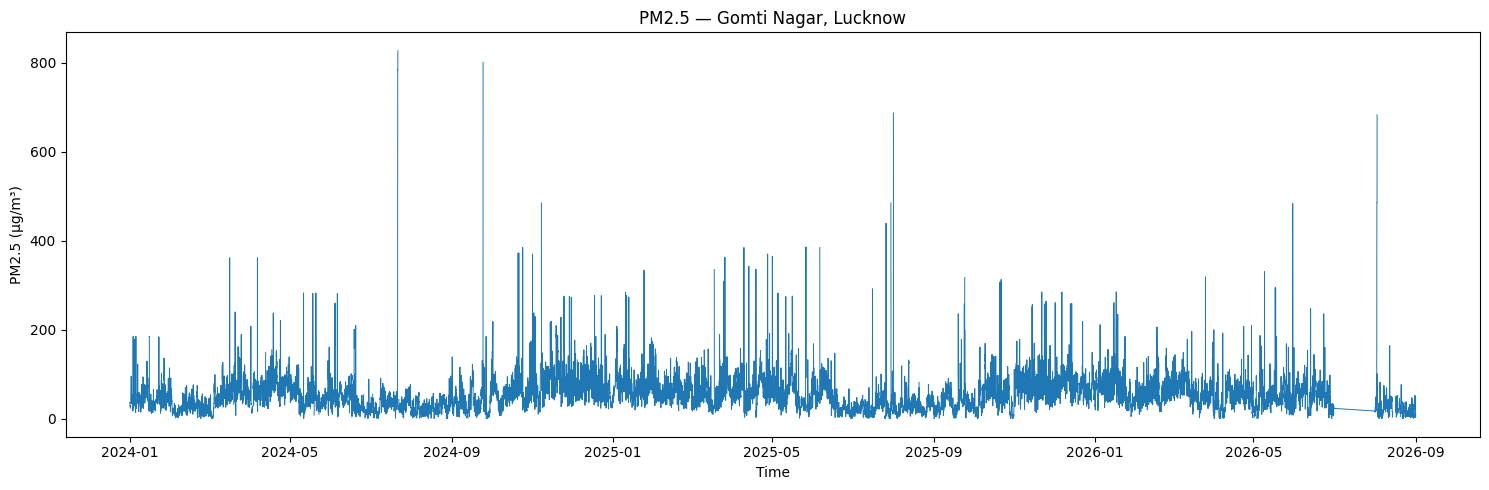

In [5]:
# PM2.5 over time

plt.figure(figsize=(15, 5))
plt.plot(df["Timestamp"], df[TARGET], linewidth=0.7)
plt.title("PM2.5 — Gomti Nagar, Lucknow")
plt.xlabel("Time")
plt.ylabel("PM2.5 (µg/m³)")
plt.tight_layout()
plt.show()


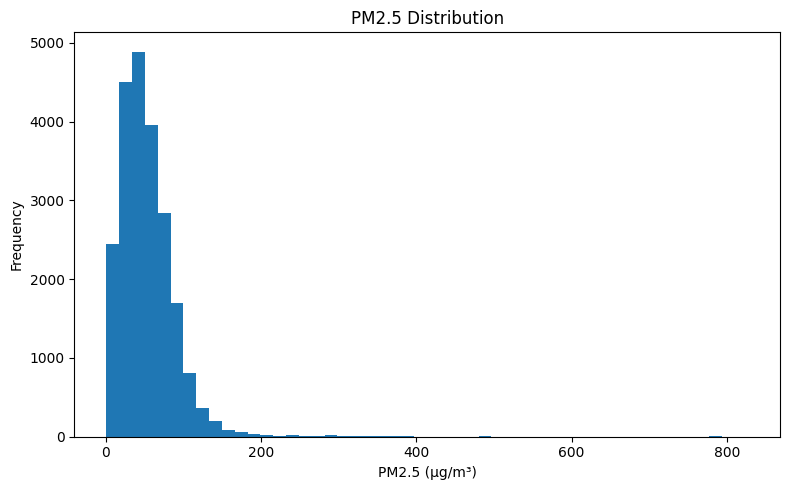

count    22064.000000
mean        53.991957
std         39.690118
min          1.000000
25%         29.250000
50%         47.750000
75%         70.750000
max        827.000000
Name: PM2.5 (µg/m³), dtype: float64

In [6]:
# PM2.5 distribution

plt.figure(figsize=(8, 5))
plt.hist(df[TARGET].dropna(), bins=50)
plt.title("PM2.5 Distribution")
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

display(df[TARGET].describe())


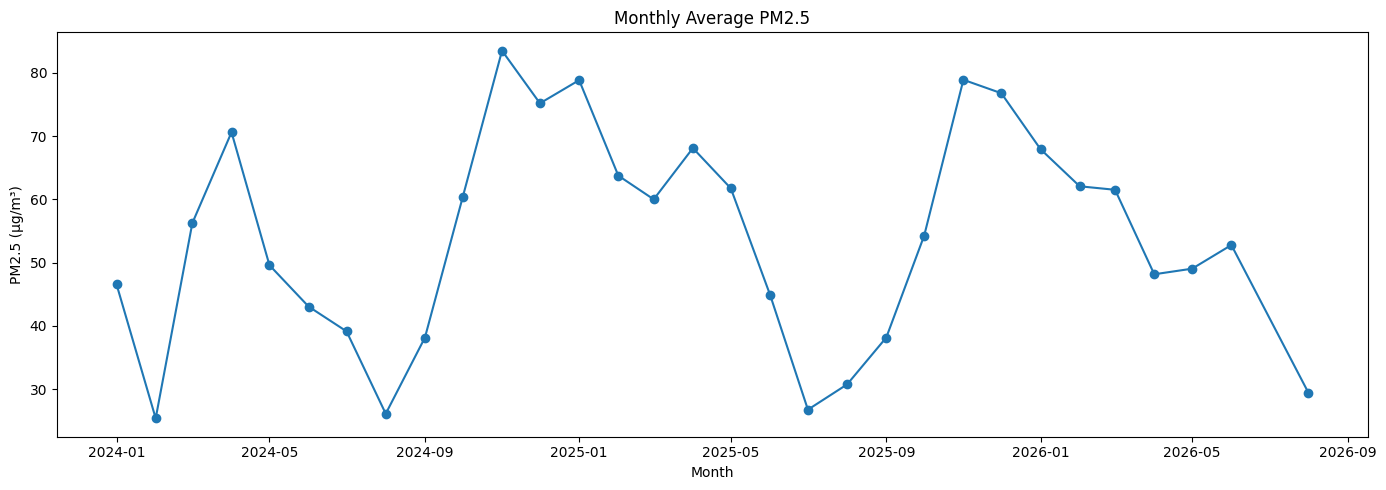

In [7]:
# Monthly PM2.5 average

monthly = (
    df.set_index("Timestamp")[TARGET]
      .resample("MS")
      .mean()
      .dropna()
)

plt.figure(figsize=(14, 5))
plt.plot(monthly.index, monthly.values, marker="o")
plt.title("Monthly Average PM2.5")
plt.xlabel("Month")
plt.ylabel("PM2.5 (µg/m³)")
plt.tight_layout()
plt.show()


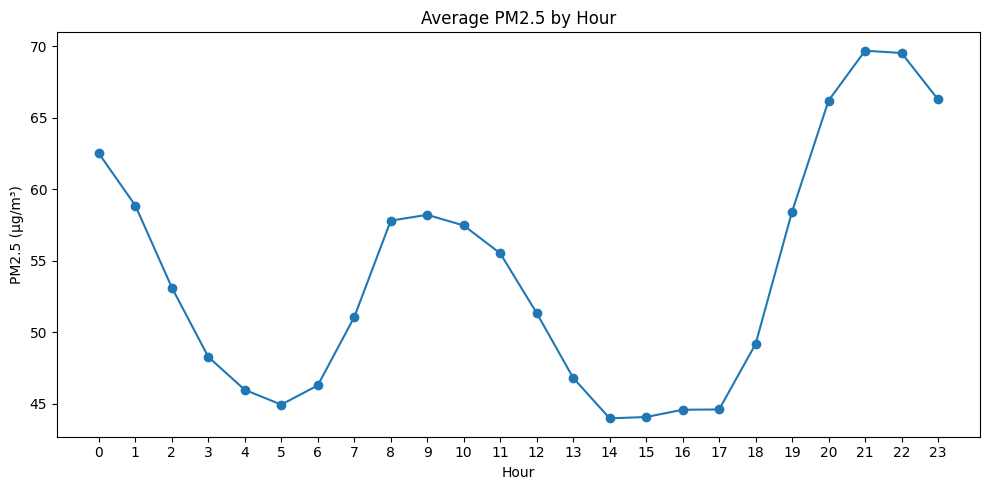

In [8]:
# Hour-of-day pattern

hourly_avg = df.groupby(df["Timestamp"].dt.hour)[TARGET].mean()

plt.figure(figsize=(10, 5))
plt.plot(hourly_avg.index, hourly_avg.values, marker="o")
plt.title("Average PM2.5 by Hour")
plt.xlabel("Hour")
plt.ylabel("PM2.5 (µg/m³)")
plt.xticks(range(24))
plt.tight_layout()
plt.show()


In [9]:
# Correlation with available environmental variables

candidate_cols = [
    TARGET, "PM10 (µg/m³)", "NO (µg/m³)", "NO2 (µg/m³)",
    "NOx (ppb)", "NH3 (µg/m³)", "SO2 (µg/m³)", "CO (mg/m³)",
    "Ozone (µg/m³)", "AT (°C)", "RH (%)", "WS (m/s)",
    "WD (deg)", "RF (mm)", "SR (W/mt2)", "BP (mmHg)", "VWS (m/s)"
]

corr_cols = [c for c in candidate_cols if c in df.columns]
display(df[corr_cols].corr(numeric_only=True)[TARGET].sort_values(ascending=False).to_frame("correlation"))


,correlation
PM2.5 (µg/m³),1.000000
PM10 (µg/m³),0.948915
WD (deg),0.069081
SO2 (µg/m³),0.035693
VWS (m/s),-0.001616
RF (mm),-0.025354
SR (W/mt2),-0.033928
CO (mg/m³),-0.060332
BP (mmHg),-0.082483
NOx (ppb),-0.083606


## 6. PM2.5 24-Hour Forecasting

We use historical PM2.5 behaviour plus calendar features.

The target is:

**PM2.5 at time t + 24 hours**


In [10]:
# 6.1 Feature engineering

data = df.copy()

# Calendar features
data["hour"] = data["Timestamp"].dt.hour
data["day_of_week"] = data["Timestamp"].dt.dayofweek
data["month"] = data["Timestamp"].dt.month
data["day_of_year"] = data["Timestamp"].dt.dayofyear
data["is_weekend"] = (data["day_of_week"] >= 5).astype(int)

# Cyclic time features
data["hour_sin"] = np.sin(2 * np.pi * data["hour"] / 24)
data["hour_cos"] = np.cos(2 * np.pi * data["hour"] / 24)
data["month_sin"] = np.sin(2 * np.pi * data["month"] / 12)
data["month_cos"] = np.cos(2 * np.pi * data["month"] / 12)

# PM2.5 lag features
for lag in [1, 3, 6, 12, 24, 48, 72, 168]:
    data[f"pm25_lag_{lag}"] = data[TARGET].shift(lag)

# Rolling statistics use only previous observations
for window in [6, 12, 24, 72]:
    data[f"pm25_roll_mean_{window}"] = data[TARGET].shift(1).rolling(window).mean()
    data[f"pm25_roll_std_{window}"] = data[TARGET].shift(1).rolling(window).std()

# 24-hour future target
data["target_pm25_24h"] = data[TARGET].shift(-FORECAST_HORIZON)

FEATURES = [
    "hour", "day_of_week", "month", "day_of_year", "is_weekend",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "pm25_lag_1", "pm25_lag_3", "pm25_lag_6", "pm25_lag_12",
    "pm25_lag_24", "pm25_lag_48", "pm25_lag_72", "pm25_lag_168",
    "pm25_roll_mean_6", "pm25_roll_std_6",
    "pm25_roll_mean_12", "pm25_roll_std_12",
    "pm25_roll_mean_24", "pm25_roll_std_24",
    "pm25_roll_mean_72", "pm25_roll_std_72"
]

model_data = (
    data[["Timestamp", TARGET, "target_pm25_24h"] + FEATURES]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)

print("Final ML rows:", len(model_data))
print("Features:", len(FEATURES))


Final ML rows: 14920
Features: 25


In [11]:
# 6.2 Time-based train/test split

train = model_data[model_data["Timestamp"].dt.year < 2026].copy()
test = model_data[model_data["Timestamp"].dt.year == 2026].copy()

# Safety fallback if 2026 is unavailable
if len(test) == 0:
    split = int(len(model_data) * 0.8)
    train = model_data.iloc[:split].copy()
    test = model_data.iloc[split:].copy()

X_train = train[FEATURES]
y_train = train["target_pm25_24h"]

X_test = test[FEATURES]
y_test = test["target_pm25_24h"]

print("Train rows:", len(train))
print("Test rows :", len(test))
print("Train period:", train["Timestamp"].min(), "to", train["Timestamp"].max())
print("Test period :", test["Timestamp"].min(), "to", test["Timestamp"].max())


Train rows: 11057
Test rows : 3863
Train period: 2024-01-11 17:00:00 to 2025-12-31 23:00:00
Test period : 2026-01-01 00:00:00 to 2026-08-30 23:00:00


In [12]:
# 7. Random Forest

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest MAE : {rf_mae:.3f}")
print(f"Random Forest RMSE: {rf_rmse:.3f}")
print(f"Random Forest R²  : {rf_r2:.3f}")


Random Forest MAE : 20.898
Random Forest RMSE: 32.175
Random Forest R²  : 0.037


In [13]:
# 8. HistGradientBoosting

hgb = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=RANDOM_STATE
)

hgb.fit(X_train, y_train)
hgb_pred = hgb.predict(X_test)

hgb_mae = mean_absolute_error(y_test, hgb_pred)
hgb_rmse = np.sqrt(mean_squared_error(y_test, hgb_pred))
hgb_r2 = r2_score(y_test, hgb_pred)

print(f"HistGradientBoosting MAE : {hgb_mae:.3f}")
print(f"HistGradientBoosting RMSE: {hgb_rmse:.3f}")
print(f"HistGradientBoosting R²  : {hgb_r2:.3f}")


HistGradientBoosting MAE : 21.549
HistGradientBoosting RMSE: 31.290
HistGradientBoosting R²  : 0.089


In [14]:
# 9. Select best forecasting model

results = pd.DataFrame({
    "Model": ["Random Forest", "HistGradientBoosting"],
    "MAE": [rf_mae, hgb_mae],
    "RMSE": [rf_rmse, hgb_rmse],
    "R2": [rf_r2, hgb_r2]
}).sort_values("MAE").reset_index(drop=True)

display(results)

if hgb_mae <= rf_mae:
    best_model = hgb
    best_pred = hgb_pred
    best_model_name = "HistGradientBoosting"
else:
    best_model = rf
    best_pred = rf_pred
    best_model_name = "Random Forest"

print("Selected model:", best_model_name)


,Model,MAE,RMSE,R2
0,Random Forest,20.897639,32.174975,0.036853
1,HistGradientBoosting,21.548650,31.289910,0.089113


Selected model: Random Forest


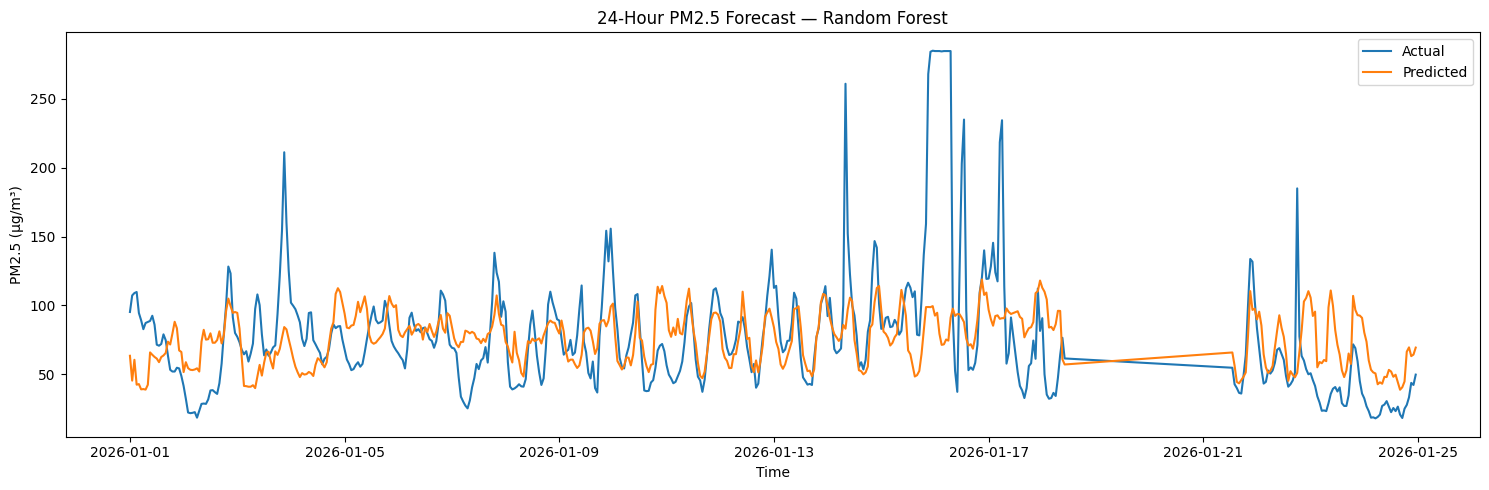

In [15]:
# 10. Actual vs predicted

n = min(500, len(test))

plt.figure(figsize=(15, 5))
plt.plot(test["Timestamp"].iloc[:n], y_test.iloc[:n].values, label="Actual")
plt.plot(test["Timestamp"].iloc[:n], best_pred[:n], label="Predicted")
plt.title(f"24-Hour PM2.5 Forecast — {best_model_name}")
plt.xlabel("Time")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.tight_layout()
plt.show()


MAE : 20.89763929702203
RMSE: 32.1749754167205
R²  : 0.03685328962007928


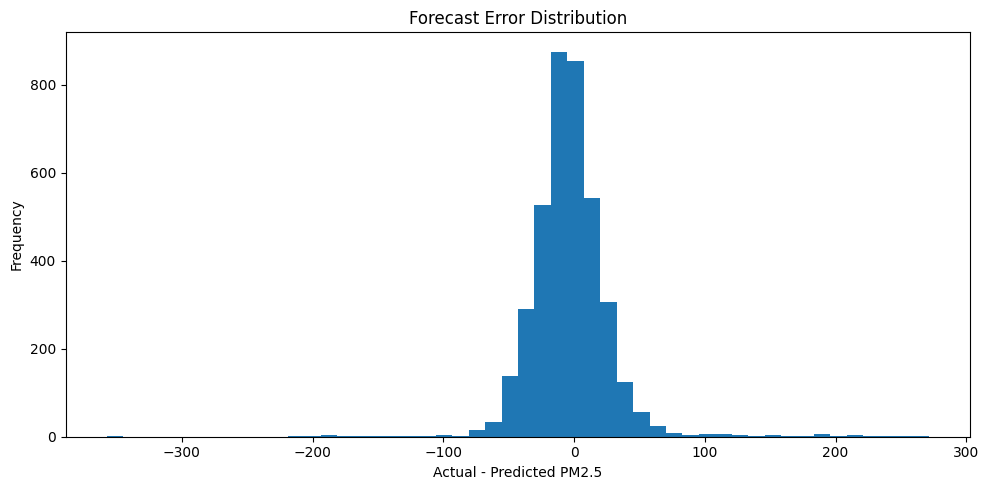

In [16]:
# 11. Forecast error analysis

errors = y_test.values - best_pred

print("MAE :", mean_absolute_error(y_test, best_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, best_pred)))
print("R²  :", r2_score(y_test, best_pred))

plt.figure(figsize=(10, 5))
plt.hist(errors, bins=50)
plt.title("Forecast Error Distribution")
plt.xlabel("Actual - Predicted PM2.5")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


,importance
pm25_lag_1,0.228593
pm25_roll_mean_24,0.107353
pm25_lag_24,0.084441
pm25_roll_std_72,0.071218
pm25_roll_mean_72,0.047846
day_of_year,0.042892
pm25_lag_12,0.041036
pm25_roll_std_12,0.039642
pm25_roll_std_24,0.039369
pm25_lag_168,0.034091


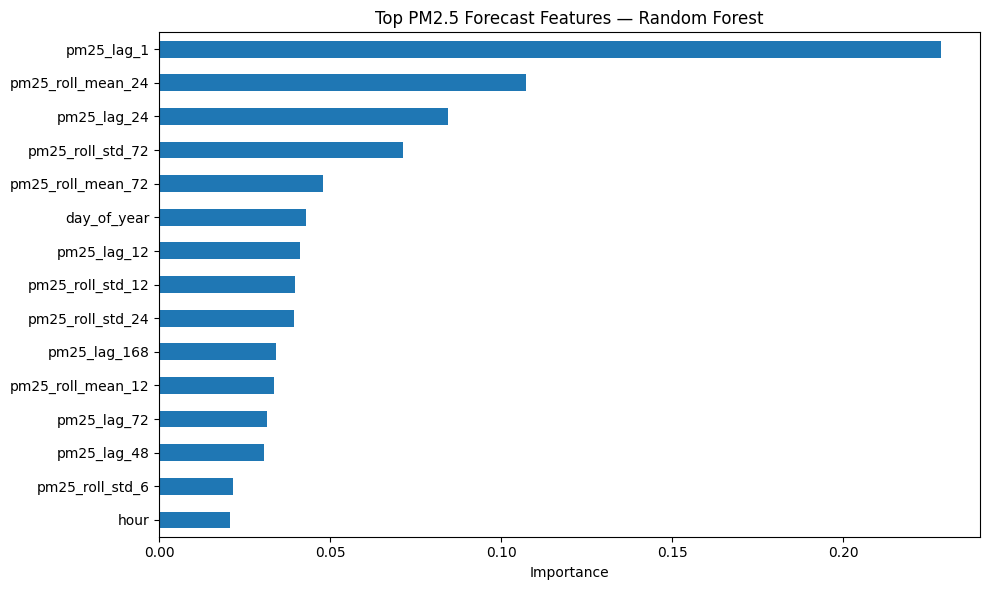

In [17]:
# 12. Feature importance for Random Forest
# HistGradientBoosting does not expose feature_importances_.

importance = pd.Series(
    rf.feature_importances_,
    index=FEATURES
).sort_values(ascending=False).head(15)

display(importance.to_frame("importance"))

plt.figure(figsize=(10, 6))
importance.sort_values().plot(kind="barh")
plt.title("Top PM2.5 Forecast Features — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


# DAY 2 — Environmental Intelligence

## 13. Anomaly Detection

We use **Isolation Forest** to flag unusual PM2.5 observations.

An anomaly means:

> The observation is unusual compared with the normal pattern in the training data.

It is a **screening signal**, not proof of a violation.


In [18]:
# 13. Prepare anomaly features

anomaly_data = df[["Timestamp", TARGET]].copy()

# Add useful pollution/context variables when available
for col in ["PM10 (µg/m³)", "NO2 (µg/m³)", "SO2 (µg/m³)", "CO (mg/m³)", "Ozone (µg/m³)", "AT (°C)", "RH (%)", "WS (m/s)"]:
    if col in df.columns:
        anomaly_data[col] = df[col]

# Time features
anomaly_data["hour"] = anomaly_data["Timestamp"].dt.hour
anomaly_data["day_of_week"] = anomaly_data["Timestamp"].dt.dayofweek

# Fill missing numeric values with median
anomaly_features = [c for c in anomaly_data.columns if c not in ["Timestamp"]]
anomaly_X = anomaly_data[anomaly_features].copy()
anomaly_X = anomaly_X.fillna(anomaly_X.median(numeric_only=True))
anomaly_X = anomaly_X.replace([np.inf, -np.inf], np.nan).fillna(0)

print("Anomaly features:", anomaly_features)


Anomaly features: ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)', 'CO (mg/m³)', 'Ozone (µg/m³)', 'AT (°C)', 'RH (%)', 'WS (m/s)', 'hour', 'day_of_week']


In [19]:
# 14. Train Isolation Forest

iso = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=RANDOM_STATE
)

anomaly_data["anomaly_label"] = iso.fit_predict(anomaly_X)
anomaly_data["anomaly_score"] = -iso.score_samples(anomaly_X)

# -1 = anomaly, +1 = normal
anomaly_data["is_anomaly"] = (anomaly_data["anomaly_label"] == -1).astype(int)

print("Anomalies detected:", int(anomaly_data["is_anomaly"].sum()))
print("Anomaly percentage:", round(anomaly_data["is_anomaly"].mean() * 100, 2), "%")


Anomalies detected: 679
Anomaly percentage: 3.0 %


In [20]:
# 15. Show detected anomalies

anomalies = (
    anomaly_data[anomaly_data["is_anomaly"] == 1]
    [["Timestamp", TARGET, "anomaly_score"]]
    .sort_values("anomaly_score", ascending=False)
)

display(anomalies.head(20))


,Timestamp,PM2.5 (µg/m³),anomaly_score
1966,2024-03-22 22:00:00,162.25,0.701869
1967,2024-03-22 23:00:00,132.25,0.692564
1989,2024-03-23 21:00:00,121.00,0.681689
2026,2024-03-25 10:00:00,156.00,0.677332
1990,2024-03-23 22:00:00,137.25,0.676260
1988,2024-03-23 20:00:00,107.00,0.673365
1968,2024-03-23 00:00:00,117.00,0.673117
1976,2024-03-23 08:00:00,152.25,0.672151
2017,2024-03-25 01:00:00,135.50,0.670148
2027,2024-03-25 11:00:00,140.00,0.669764


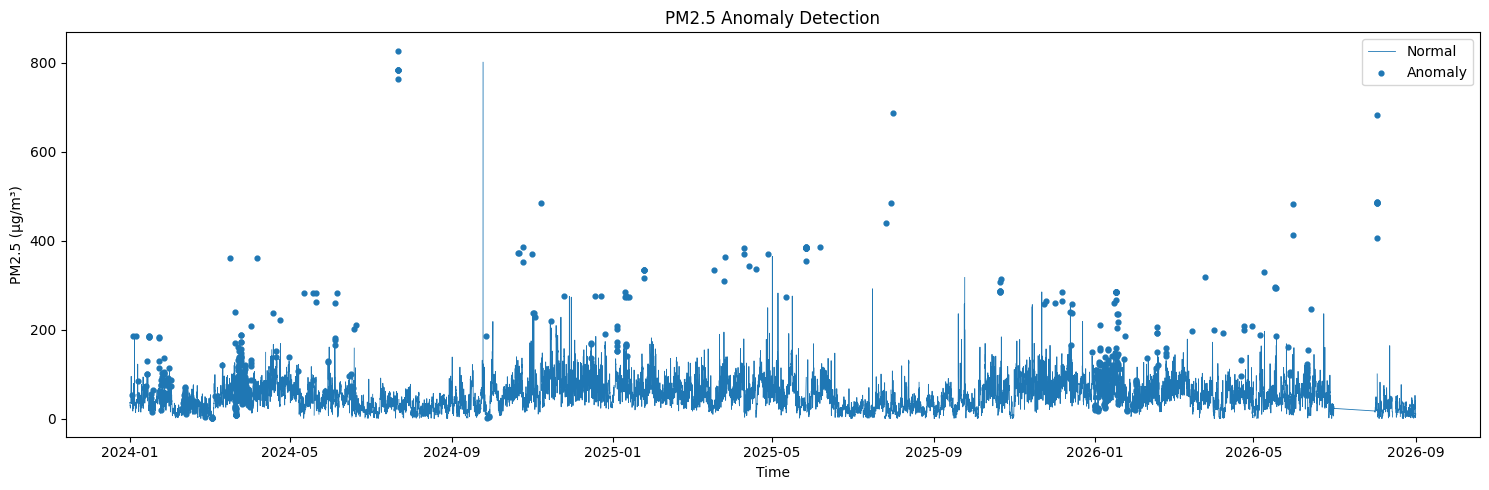

In [21]:
# 16. Visualize anomalies

plt.figure(figsize=(15, 5))

normal = anomaly_data["is_anomaly"] == 0
abnormal = anomaly_data["is_anomaly"] == 1

plt.plot(
    anomaly_data.loc[normal, "Timestamp"],
    anomaly_data.loc[normal, TARGET],
    linewidth=0.6,
    label="Normal"
)

plt.scatter(
    anomaly_data.loc[abnormal, "Timestamp"],
    anomaly_data.loc[abnormal, TARGET],
    s=12,
    label="Anomaly"
)

plt.title("PM2.5 Anomaly Detection")
plt.xlabel("Time")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.tight_layout()
plt.show()


## 17. Risk Scoring

We combine:
- Current PM2.5
- 24-hour predicted PM2.5
- Anomaly signal

to create a **0–100 prototype risk score**.


In [22]:
# 17. Build risk dataset

risk_df = test[["Timestamp", TARGET, "target_pm25_24h"]].copy()
risk_df = risk_df.rename(columns={"target_pm25_24h": "actual_pm25_24h"})

# Add model forecast
risk_df["predicted_pm25_24h"] = best_pred

# Match anomaly information by timestamp
risk_lookup = anomaly_data[["Timestamp", "is_anomaly", "anomaly_score"]]
risk_df = risk_df.merge(risk_lookup, on="Timestamp", how="left")

risk_df["is_anomaly"] = risk_df["is_anomaly"].fillna(0).astype(int)
risk_df["anomaly_score"] = risk_df["anomaly_score"].fillna(0)

# Clip values for stable scoring
current_component = np.clip(risk_df[TARGET] / 200 * 40, 0, 40)
forecast_component = np.clip(risk_df["predicted_pm25_24h"] / 200 * 40, 0, 40)
anomaly_component = risk_df["is_anomaly"] * 20

risk_df["risk_score"] = np.clip(
    current_component + forecast_component + anomaly_component,
    0,
    100
)

def risk_category(score):
    if score < 25:
        return "Low"
    elif score < 50:
        return "Moderate"
    elif score < 75:
        return "High"
    return "Critical"

risk_df["risk_category"] = risk_df["risk_score"].apply(risk_category)

display(
    risk_df[
        ["Timestamp", TARGET, "predicted_pm25_24h", "is_anomaly", "risk_score", "risk_category"]
    ].head(20)
)


,Timestamp,PM2.5 (µg/m³),predicted_pm25_24h,is_anomaly,risk_score,risk_category
0,2026-01-01 00:00:00,28.50,63.431051,1,38.386210,Moderate
1,2026-01-01 01:00:00,30.50,45.396560,1,35.179312,Moderate
2,2026-01-01 02:00:00,27.75,60.520259,1,37.654052,Moderate
3,2026-01-01 03:00:00,26.00,42.448260,1,33.689652,Moderate
4,2026-01-01 04:00:00,21.75,42.875579,1,32.925116,Moderate
5,2026-01-01 05:00:00,20.00,39.059549,1,31.811910,Moderate
6,2026-01-01 06:00:00,20.00,39.253188,0,11.850638,Low
7,2026-01-01 07:00:00,28.50,38.874417,1,33.474883,Moderate
8,2026-01-01 08:00:00,51.75,42.400656,0,18.830131,Low
9,2026-01-01 09:00:00,66.00,65.886177,0,26.377235,Moderate


risk_category
Low         2313
Moderate    1384
High         144
Critical      22
Name: count, dtype: int64


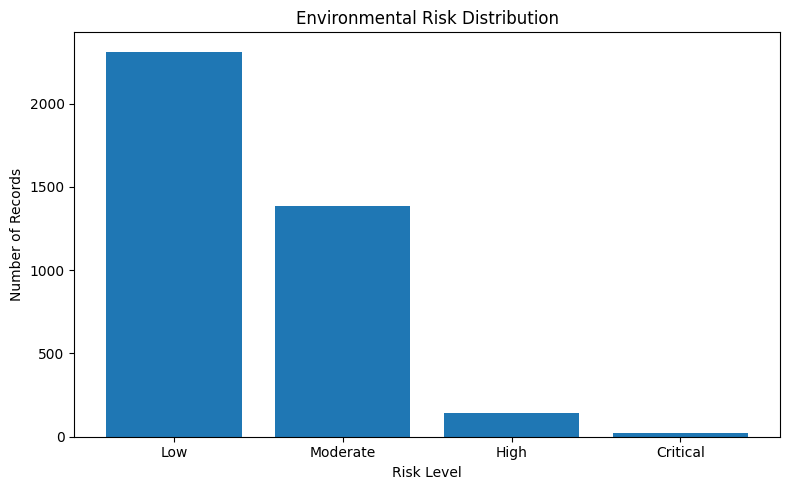

In [23]:
# 18. Risk distribution

print(risk_df["risk_category"].value_counts())

risk_order = ["Low", "Moderate", "High", "Critical"]
risk_counts = risk_df["risk_category"].value_counts().reindex(risk_order, fill_value=0)

plt.figure(figsize=(8, 5))
plt.bar(risk_counts.index, risk_counts.values)
plt.title("Environmental Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()


## 19. Inspection Prioritization

For the current prototype we have **one monitoring station**, so inspection priority is generated for **high-risk time/events**.

When the full system contains multiple stations/industries, the same logic will rank locations.


In [24]:
# Create inspection priority

inspection = risk_df.copy()

# Priority score emphasizes high risk and anomalies
inspection["inspection_priority_score"] = (
    inspection["risk_score"] * 0.8
    + inspection["is_anomaly"] * 20
)

inspection["priority_level"] = pd.cut(
    inspection["inspection_priority_score"],
    bins=[-np.inf, 30, 55, 75, np.inf],
    labels=["Low", "Medium", "High", "Urgent"]
)

inspection = inspection.sort_values(
    "inspection_priority_score",
    ascending=False
).reset_index(drop=True)

inspection["priority_rank"] = np.arange(1, len(inspection) + 1)

inspection_output = inspection[
    [
        "priority_rank",
        "Timestamp",
        TARGET,
        "predicted_pm25_24h",
        "is_anomaly",
        "risk_score",
        "risk_category",
        "inspection_priority_score",
        "priority_level"
    ]
]

display(inspection_output.head(20))


,priority_rank,Timestamp,PM2.5 (µg/m³),predicted_pm25_24h,is_anomaly,risk_score,risk_category,inspection_priority_score,priority_level
0,1,2026-01-16 21:00:00,268.00,118.792825,1,83.758565,Critical,87.006852,Urgent
1,2,2026-01-04 21:00:00,211.25,112.513173,1,82.502635,Critical,86.002108,Urgent
2,3,2026-02-16 23:00:00,206.25,110.039350,1,82.007870,Critical,85.606296,Urgent
3,4,2026-01-16 23:00:00,285.00,109.351177,1,81.870235,Critical,85.496188,Urgent
4,5,2026-01-16 22:00:00,284.25,107.648745,1,81.529749,Critical,85.223799,Urgent
5,6,2026-01-17 00:00:00,284.75,96.845679,1,79.369136,Critical,83.495309,Urgent
6,7,2026-01-17 13:00:00,235.00,95.776551,1,79.155310,Critical,83.324248,Urgent
7,8,2026-04-01 01:00:00,200.00,95.607897,1,79.121579,Critical,83.297264,Urgent
8,9,2026-01-15 08:00:00,261.00,95.527155,1,79.105431,Critical,83.284345,Urgent
9,10,2026-01-17 04:00:00,284.75,92.802248,1,78.560450,Critical,82.848360,Urgent


In [25]:
# 20. Top 10 inspection events for the dashboard

top_inspections = inspection_output.head(10).copy()

print("TOP INSPECTION PRIORITIES")
display(top_inspections)


TOP INSPECTION PRIORITIES


,priority_rank,Timestamp,PM2.5 (µg/m³),predicted_pm25_24h,is_anomaly,risk_score,risk_category,inspection_priority_score,priority_level
0,1,2026-01-16 21:00:00,268.00,118.792825,1,83.758565,Critical,87.006852,Urgent
1,2,2026-01-04 21:00:00,211.25,112.513173,1,82.502635,Critical,86.002108,Urgent
2,3,2026-02-16 23:00:00,206.25,110.039350,1,82.007870,Critical,85.606296,Urgent
3,4,2026-01-16 23:00:00,285.00,109.351177,1,81.870235,Critical,85.496188,Urgent
4,5,2026-01-16 22:00:00,284.25,107.648745,1,81.529749,Critical,85.223799,Urgent
5,6,2026-01-17 00:00:00,284.75,96.845679,1,79.369136,Critical,83.495309,Urgent
6,7,2026-01-17 13:00:00,235.00,95.776551,1,79.155310,Critical,83.324248,Urgent
7,8,2026-04-01 01:00:00,200.00,95.607897,1,79.121579,Critical,83.297264,Urgent
8,9,2026-01-15 08:00:00,261.00,95.527155,1,79.105431,Critical,83.284345,Urgent
9,10,2026-01-17 04:00:00,284.75,92.802248,1,78.560450,Critical,82.848360,Urgent


# 21. Latest Environmental Intelligence

Create the values that the future FastAPI backend can return to the React dashboard.


In [26]:
# Latest available forecast/risk information

latest_features = model_data.iloc[[-1]]
latest_timestamp = latest_features["Timestamp"].iloc[0]

latest_prediction = float(best_model.predict(latest_features[FEATURES])[0])

latest_anomaly_row = anomaly_data.iloc[-1]
latest_anomaly = int(latest_anomaly_row["is_anomaly"])

# Simple latest risk calculation
latest_current_pm25 = float(df[TARGET].dropna().iloc[-1])

latest_risk_score = float(np.clip(
    (latest_current_pm25 / 200 * 40)
    + (latest_prediction / 200 * 40)
    + (latest_anomaly * 20),
    0,
    100
))

latest_risk = risk_category(latest_risk_score)

latest_intelligence = {
    "location": "Gomti Nagar, Lucknow, Uttar Pradesh",
    "timestamp": str(latest_timestamp),
    "current_pm25": round(latest_current_pm25, 2),
    "predicted_pm25_24h": round(latest_prediction, 2),
    "anomaly_detected": bool(latest_anomaly),
    "risk_score": round(latest_risk_score, 2),
    "risk_category": latest_risk,
    "forecast_model": best_model_name
}

latest_intelligence


{'location': 'Gomti Nagar, Lucknow, Uttar Pradesh',
 'timestamp': '2026-08-30 23:00:00',
 'current_pm25': 11.33,
 'predicted_pm25_24h': 31.56,
 'anomaly_detected': False,
 'risk_score': 8.58,
 'risk_category': 'Low',
 'forecast_model': 'Random Forest'}

# 22. Save ML artifacts and outputs

These files will later be used by the **FastAPI backend**.


In [27]:
# Save forecasting model

forecast_package = {
    "model": best_model,
    "features": FEATURES,
    "target": TARGET,
    "forecast_horizon_hours": FORECAST_HORIZON,
    "location": "Gomti Nagar, Lucknow, Uttar Pradesh",
    "model_name": best_model_name
}

forecast_path = os.path.join(MODEL_DIR, "pm25_forecaster_24h.joblib")
joblib.dump(forecast_package, forecast_path)

# Save anomaly model
anomaly_path = os.path.join(MODEL_DIR, "pm25_anomaly_detector.joblib")
joblib.dump(
    {
        "model": iso,
        "features": anomaly_features,
        "location": "Gomti Nagar, Lucknow, Uttar Pradesh"
    },
    anomaly_path
)

# Save datasets and results
model_data.to_csv(
    os.path.join(PROCESSED_DIR, "pm25_ml_dataset.csv"),
    index=False
)

results.to_csv(
    os.path.join(MODEL_DIR, "pm25_model_metrics.csv"),
    index=False
)

risk_df.to_csv(
    os.path.join(OUTPUT_DIR, "risk_results.csv"),
    index=False
)

inspection_output.to_csv(
    os.path.join(OUTPUT_DIR, "inspection_priority.csv"),
    index=False
)

with open(os.path.join(OUTPUT_DIR, "latest_intelligence.json"), "w", encoding="utf-8") as f:
    import json
    json.dump(latest_intelligence, f, indent=4)

print("Saved:")
print("1.", forecast_path)
print("2.", anomaly_path)
print("3.", os.path.join(PROCESSED_DIR, "pm25_ml_dataset.csv"))
print("4.", os.path.join(MODEL_DIR, "pm25_model_metrics.csv"))
print("5.", os.path.join(OUTPUT_DIR, "risk_results.csv"))
print("6.", os.path.join(OUTPUT_DIR, "inspection_priority.csv"))
print("7.", os.path.join(OUTPUT_DIR, "latest_intelligence.json"))


Saved:
1. C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\models\pm25_forecaster_24h.joblib
2. C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\models\pm25_anomaly_detector.joblib
3. C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\data\processed\pm25_ml_dataset.csv
4. C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\models\pm25_model_metrics.csv
5. C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\outputs\risk_results.csv
6. C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\outputs\inspection_priority.csv
7. C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\outputs\latest_intelligence.json


# ✅ Day 1 + Day 2 Complete

### Forecasting
- PM2.5 24-hour forecasting
- Random Forest
- HistGradientBoosting
- Best model selection
- Evaluation and plots

### Environmental Intelligence
- Isolation Forest anomaly detection
- 0–100 risk score
- Low / Moderate / High / Critical risk
- Inspection/event prioritization
- Dashboard-ready latest intelligence

### Next in the 7-day plan
**Day 3 → Policy Simulator + Action Recommendation**


# 🚀 Day 3 — Policy Intelligence Engine

## Goal
Turn the forecasting/risk outputs from Day 1–2 into a **decision-support layer**:

**Forecast → Policy Scenario → Impact Estimate → Budget Recommendation → Verification**

> **Important:** Policy impacts in this prototype are **scenario estimates**, not causal claims. The current Gomti Nagar dataset does not contain direct intervention variables such as vehicle activity, industrial production, or policy implementation dates. Therefore, the simulator uses transparent, user-editable scenario assumptions.

## 23. Policy Scenario Library

We define a small policy library for the prototype.  
Each policy has:
- a lever
- an assumed PM2.5 reduction percentage
- a relative budget requirement
- an implementation priority

The assumed impact is deliberately kept separate from the ML forecast so the dashboard can clearly label it as a **scenario estimate**.

In [28]:
# 23. Policy Scenario Library

policy_library = pd.DataFrame([
    {
        "policy_id": "P01",
        "policy": "Reduce heavy vehicle activity",
        "lever": "Traffic / heavy vehicles",
        "assumed_pm25_reduction_pct": 5.0,
        "budget_units": 3,
        "description": "Scenario: reduce heavy-vehicle activity during high-risk periods."
    },
    {
        "policy_id": "P02",
        "policy": "Improve industrial emission efficiency",
        "lever": "Industrial emissions",
        "assumed_pm25_reduction_pct": 8.0,
        "budget_units": 4,
        "description": "Scenario: improve emission-control efficiency at priority facilities."
    },
    {
        "policy_id": "P03",
        "policy": "Shift trips to public transport",
        "lever": "Transport demand",
        "assumed_pm25_reduction_pct": 4.0,
        "budget_units": 2,
        "description": "Scenario: shift a portion of private trips to public transport."
    },
    {
        "policy_id": "P04",
        "policy": "Cleaner energy transition",
        "lever": "Fuel / energy",
        "assumed_pm25_reduction_pct": 6.0,
        "budget_units": 5,
        "description": "Scenario: increase cleaner energy/fuel usage."
    },
    {
        "policy_id": "P05",
        "policy": "Targeted green intervention",
        "lever": "Local mitigation",
        "assumed_pm25_reduction_pct": 2.5,
        "budget_units": 1,
        "description": "Scenario: targeted local mitigation in priority areas."
    }
])

display(policy_library)
print("\nThese percentages are prototype assumptions and must be replaced/calibrated with intervention data in a production system.")

,policy_id,policy,lever,assumed_pm25_reduction_pct,budget_units,description
0,P01,Reduce heavy vehicle activity,Traffic / heavy vehicles,5.0,3,Scenario: reduce heavy-vehicle activity during...
1,P02,Improve industrial emission efficiency,Industrial emissions,8.0,4,Scenario: improve emission-control efficiency ...
2,P03,Shift trips to public transport,Transport demand,4.0,2,Scenario: shift a portion of private trips to ...
3,P04,Cleaner energy transition,Fuel / energy,6.0,5,Scenario: increase cleaner energy/fuel usage.
4,P05,Targeted green intervention,Local mitigation,2.5,1,Scenario: targeted local mitigation in priorit...



These percentages are prototype assumptions and must be replaced/calibrated with intervention data in a production system.


## 24. Policy What-If Simulator

The simulator starts from the latest ML forecast and estimates:

- baseline PM2.5
- scenario PM2.5
- estimated reduction
- estimated reduction percentage

This does **not** retrain the forecasting model or claim that the policy will definitely cause that reduction.

,policy_id,policy,baseline_pm25,projected_pm25,estimated_reduction,assumed_reduction_pct,budget_units,estimate_type
1,P02,Improve industrial emission efficiency,31.56,29.04,2.53,8.0,4,Scenario estimate
3,P04,Cleaner energy transition,31.56,29.67,1.89,6.0,5,Scenario estimate
0,P01,Reduce heavy vehicle activity,31.56,29.99,1.58,5.0,3,Scenario estimate
2,P03,Shift trips to public transport,31.56,30.30,1.26,4.0,2,Scenario estimate
4,P05,Targeted green intervention,31.56,30.77,0.79,2.5,1,Scenario estimate


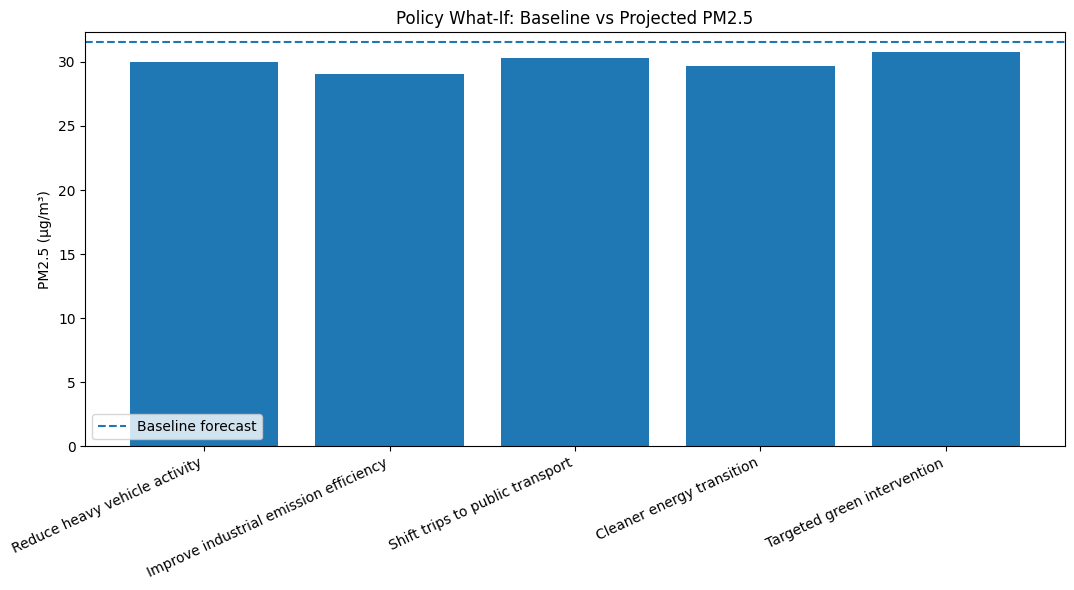

In [29]:
# 24. Policy What-If Simulator

baseline_pm25 = float(latest_prediction)

def simulate_policy(baseline, policy_row):
    reduction_pct = float(policy_row["assumed_pm25_reduction_pct"])
    projected = baseline * (1 - reduction_pct / 100)

    return {
        "policy_id": policy_row["policy_id"],
        "policy": policy_row["policy"],
        "baseline_pm25": round(baseline, 2),
        "projected_pm25": round(projected, 2),
        "estimated_reduction": round(baseline - projected, 2),
        "assumed_reduction_pct": reduction_pct,
        "budget_units": int(policy_row["budget_units"]),
        "estimate_type": "Scenario estimate"
    }

policy_results = pd.DataFrame(
    [simulate_policy(baseline_pm25, row) for _, row in policy_library.iterrows()]
)

display(policy_results.sort_values("projected_pm25"))

# Visual comparison
plt.figure(figsize=(11, 6))
plt.bar(policy_results["policy"], policy_results["projected_pm25"])
plt.axhline(baseline_pm25, linestyle="--", label="Baseline forecast")
plt.ylabel("PM2.5 (µg/m³)")
plt.title("Policy What-If: Baseline vs Projected PM2.5")
plt.xticks(rotation=25, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## 25. Budget-Aware Action Recommendation

For the prototype, `budget_units` are **relative planning units**, not rupee costs.

We rank policies using:

**Impact per budget unit = estimated PM2.5 reduction / budget units**

This gives the government user a transparent way to compare interventions when resources are limited.

In [30]:
# 25. Budget-Aware Action Recommendation

policy_results["impact_per_budget_unit"] = (
    policy_results["estimated_reduction"] / policy_results["budget_units"]
)

recommendations = policy_results.sort_values(
    ["impact_per_budget_unit", "estimated_reduction"],
    ascending=[False, False]
).reset_index(drop=True)

recommendations["recommendation_rank"] = np.arange(1, len(recommendations) + 1)

recommendations = recommendations[
    [
        "recommendation_rank",
        "policy_id",
        "policy",
        "projected_pm25",
        "estimated_reduction",
        "assumed_reduction_pct",
        "budget_units",
        "impact_per_budget_unit",
        "estimate_type"
    ]
]

display(recommendations)

print("\nTop prototype recommendation:")
display(recommendations.head(1))

,recommendation_rank,policy_id,policy,projected_pm25,estimated_reduction,assumed_reduction_pct,budget_units,impact_per_budget_unit,estimate_type
0,1,P05,Targeted green intervention,30.77,0.79,2.5,1,0.790000,Scenario estimate
1,2,P02,Improve industrial emission efficiency,29.04,2.53,8.0,4,0.632500,Scenario estimate
2,3,P03,Shift trips to public transport,30.30,1.26,4.0,2,0.630000,Scenario estimate
3,4,P01,Reduce heavy vehicle activity,29.99,1.58,5.0,3,0.526667,Scenario estimate
4,5,P04,Cleaner energy transition,29.67,1.89,6.0,5,0.378000,Scenario estimate



Top prototype recommendation:


,recommendation_rank,policy_id,policy,projected_pm25,estimated_reduction,assumed_reduction_pct,budget_units,impact_per_budget_unit,estimate_type
0,1,P05,Targeted green intervention,30.77,0.79,2.5,1,0.79,Scenario estimate


## 26. Multi-Policy Scenario

Government action may involve more than one intervention.  
This prototype lets us test a selected combination.

The combined result is still a **scenario estimate**. We use a simple capped additive reduction assumption to avoid producing an impossible reduction above 100%.

In [31]:
# 26. Multi-Policy Scenario

def simulate_policy_bundle(policy_ids, baseline):
    selected = policy_library[policy_library["policy_id"].isin(policy_ids)].copy()

    if selected.empty:
        raise ValueError("No valid policy IDs were selected.")

    total_assumed_reduction = selected["assumed_pm25_reduction_pct"].sum()
    total_assumed_reduction = min(total_assumed_reduction, 80.0)

    projected = baseline * (1 - total_assumed_reduction / 100)

    return {
        "selected_policies": ", ".join(selected["policy"].tolist()),
        "baseline_pm25": round(baseline, 2),
        "combined_assumed_reduction_pct": round(total_assumed_reduction, 2),
        "projected_pm25": round(projected, 2),
        "estimated_reduction": round(baseline - projected, 2),
        "total_budget_units": int(selected["budget_units"].sum()),
        "estimate_type": "Scenario estimate"
    }

# Example bundle for the prototype
selected_policy_ids = ["P01", "P03", "P05"]
bundle_result = simulate_policy_bundle(selected_policy_ids, baseline_pm25)
bundle_result

{'selected_policies': 'Reduce heavy vehicle activity, Shift trips to public transport, Targeted green intervention',
 'baseline_pm25': 31.56,
 'combined_assumed_reduction_pct': np.float64(11.5),
 'projected_pm25': np.float64(27.93),
 'estimated_reduction': np.float64(3.63),
 'total_budget_units': 6,
 'estimate_type': 'Scenario estimate'}

## 27. Policy Verification Framework ⭐

This is the final part of the closed-loop idea:

**Predict → Prioritize → Simulate → Act → Verify**

The verification function compares:
- baseline PM2.5 before intervention
- expected PM2.5 from the selected scenario
- observed PM2.5 after intervention

Because our current dataset has **no verified policy intervention date**, we do not fabricate an observed outcome. The function is ready for real post-intervention data.

In [32]:
# 27. Policy Verification Framework

def verify_policy_effect(
    baseline_observed_pm25,
    expected_reduction_pct,
    post_policy_observed_pm25
):
    baseline_observed_pm25 = float(baseline_observed_pm25)
    post_policy_observed_pm25 = float(post_policy_observed_pm25)
    expected_reduction_pct = float(expected_reduction_pct)

    expected_pm25 = baseline_observed_pm25 * (1 - expected_reduction_pct / 100)
    observed_reduction = baseline_observed_pm25 - post_policy_observed_pm25
    observed_reduction_pct = (
        observed_reduction / baseline_observed_pm25 * 100
        if baseline_observed_pm25 != 0 else np.nan
    )

    effectiveness_pct = (
        observed_reduction_pct / expected_reduction_pct * 100
        if expected_reduction_pct != 0 else np.nan
    )

    return {
        "baseline_observed_pm25": round(baseline_observed_pm25, 2),
        "expected_pm25": round(expected_pm25, 2),
        "post_policy_observed_pm25": round(post_policy_observed_pm25, 2),
        "expected_reduction_pct": round(expected_reduction_pct, 2),
        "observed_reduction_pct": round(observed_reduction_pct, 2),
        "policy_effectiveness_pct": round(effectiveness_pct, 2),
        "note": "Effectiveness is descriptive; causal attribution requires controlled/adjusted analysis."
    }

# Verification template — intentionally no fabricated post-policy observation.
verification_template = {
    "status": "Awaiting verified post-intervention observations",
    "required_inputs": [
        "baseline observed PM2.5",
        "policy implementation date/window",
        "post-policy observed PM2.5",
        "expected scenario reduction"
    ]
}
verification_template

{'status': 'Awaiting verified post-intervention observations',
 'required_inputs': ['baseline observed PM2.5',
  'policy implementation date/window',
  'post-policy observed PM2.5',
  'expected scenario reduction']}

## 28. Pollution Displacement Check ⭐

A policy may improve one area while pollution rises in a nearby area.

For a future multi-station dataset, this function compares pre/post changes across locations and flags a simple **possible displacement signal**.

This is a screening signal, not proof of causation.

In [33]:
# 28. Pollution Displacement Check

def displacement_check(location_changes, improved_threshold=-2.0, worsened_threshold=2.0):
    """
    location_changes: DataFrame with columns:
        location, change_pct
    Negative change = improvement.
    Positive change = worsening.
    """
    required = {"location", "change_pct"}
    missing = required - set(location_changes.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    improved = location_changes[location_changes["change_pct"] <= improved_threshold]
    worsened = location_changes[location_changes["change_pct"] >= worsened_threshold]

    possible_displacement = len(improved) > 0 and len(worsened) > 0

    return {
        "improved_locations": improved["location"].tolist(),
        "worsened_locations": worsened["location"].tolist(),
        "possible_displacement_signal": possible_displacement,
        "note": "Requires multi-location post-intervention observations for meaningful use."
    }

print("Displacement checker ready for future multi-station data.")

Displacement checker ready for future multi-station data.


## 29. Day 3 Outputs

Save the policy intelligence artifacts so the future FastAPI backend can use them.

In [34]:
# 29. Save Day 3 policy intelligence artifacts

policy_results_path = os.path.join(OUTPUT_DIR, "policy_scenario_results.csv")
recommendations_path = os.path.join(OUTPUT_DIR, "policy_recommendations.csv")
bundle_path = os.path.join(OUTPUT_DIR, "policy_bundle_result.json")
verification_path = os.path.join(OUTPUT_DIR, "policy_verification_template.json")

policy_results.to_csv(policy_results_path, index=False)
recommendations.to_csv(recommendations_path, index=False)

with open(bundle_path, "w", encoding="utf-8") as f:
    json.dump(bundle_result, f, indent=4)

with open(verification_path, "w", encoding="utf-8") as f:
    json.dump(verification_template, f, indent=4)

print("Day 3 saved:")
print("1.", policy_results_path)
print("2.", recommendations_path)
print("3.", bundle_path)
print("4.", verification_path)

Day 3 saved:
1. C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\outputs\policy_scenario_results.csv
2. C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\outputs\policy_recommendations.csv
3. C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\outputs\policy_bundle_result.json
4. C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\outputs\policy_verification_template.json


# ✅ Day 3 Complete

### Policy Intelligence now includes

- ✅ Policy Scenario Library
- ✅ What-If Simulator
- ✅ Baseline vs projected PM2.5
- ✅ Budget-aware recommendation
- ✅ Multi-policy bundle simulation
- ✅ Policy verification framework
- ✅ Pollution displacement screening
- ✅ Saved backend-ready outputs

### Eco Predict ML pipeline so far

**Day 1:** Data → Features → Train/Test Split → Model Training → Evaluation  
**Day 2:** Forecast → Anomaly Detection → Risk Score → Inspection Priority  
**Day 3:** Risk → Policy Simulation → Recommendation → Verification

### Next
**Day 4 — React Frontend**


# 🚀 DAY 5 — Multi-Station Environmental Intelligence

## Goal

Extend Eco Predict from a **single-station prototype** to a **multi-station Lucknow intelligence system**.

Stations used in this prototype:

1. Gomti Nagar
2. Kendriya Vidyalaya
3. Lalbagh
4. Talkatora DIC

The Day 5 pipeline will:

**Load → Validate → Combine → Compare Stations → Build Station-wise Forecast Models → Detect Anomalies → Calculate Tomorrow Risk → Rank Stations**

> **Important:** The current CPCB real-time snapshot is useful for current station comparison, but this Day 5 notebook uses the historical hourly station folders for forecasting. Forecasting requires historical time-series data.


## 30. Day 5 Data Structure

The notebook expects this exact structure:

```text
EcoPredict/
├── data/
│   └── raw/
│       └── lucknow/
│           ├── gomti_nagar/
│           ├── kendriya_vidyalaya/
│           ├── lalbagh/
│           └── talkatora_dic/
├── frontend/
├── ml/
├── models/
└── outputs/
```

Each station folder can contain:

```text
air_2024.csv
air_2025.csv
air_2026.csv
```

The notebook automatically adds the station name from the folder, so the original CSV files do not need a `Station` column.


In [35]:
# 30.1 Multi-station paths and configuration

import os
import glob
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

# Notebook is directly inside EcoPredict/ml/.
BASE_DIR_DAY5 = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Safety: if Jupyter was launched from the EcoPredict root, use the current directory.
if not os.path.isdir(os.path.join(BASE_DIR_DAY5, "data")) and os.path.isdir(os.path.join(os.getcwd(), "data")):
    BASE_DIR_DAY5 = os.path.abspath(os.getcwd())

RAW_LUCKNOW_DIR = os.path.join(BASE_DIR_DAY5, "data", "raw", "lucknow")
PROCESSED_DIR_DAY5 = os.path.join(BASE_DIR_DAY5, "data", "processed")
MODEL_DIR_DAY5 = os.path.join(BASE_DIR_DAY5, "models", "multi_station")
OUTPUT_DIR_DAY5 = os.path.join(BASE_DIR_DAY5, "outputs", "multi_station")

for folder in [PROCESSED_DIR_DAY5, MODEL_DIR_DAY5, OUTPUT_DIR_DAY5]:
    os.makedirs(folder, exist_ok=True)

STATION_FOLDERS = {
    "Gomti Nagar": "gomti_nagar",
    "Kendriya Vidyalaya": "kendriya_vidyalaya",
    "Lalbagh": "lalbagh",
    "Talkatora DIC": "talkatora_dic"
}

TARGET_DAY5 = "PM2.5 (µg/m³)"
FORECAST_HORIZON_DAY5 = 24
RANDOM_STATE_DAY5 = 42

print("Project:", BASE_DIR_DAY5)
print("Raw Lucknow data:", RAW_LUCKNOW_DIR)
print("Stations:", list(STATION_FOLDERS.keys()))


Project: C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict
Raw Lucknow data: C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\data\raw\lucknow
Stations: ['Gomti Nagar', 'Kendriya Vidyalaya', 'Lalbagh', 'Talkatora DIC']


In [36]:
# 30.2 Verify the expected station folders and CSV files

station_file_map = {}
missing_stations = []

for station_name, folder_name in STATION_FOLDERS.items():
    folder_path = os.path.join(RAW_LUCKNOW_DIR, folder_name)
    files = sorted(glob.glob(os.path.join(folder_path, "*.csv")))
    files = [f for f in files if "2009" not in os.path.basename(f).lower()]
    station_file_map[station_name] = files

    if not os.path.isdir(folder_path):
        missing_stations.append(f"{station_name}: folder missing -> {folder_path}")
    elif not files:
        missing_stations.append(f"{station_name}: no CSV files found -> {folder_path}")

for station_name, files in station_file_map.items():
    print(f"\n{station_name}: {len(files)} CSV file(s)")
    for f in files:
        print("  -", os.path.basename(f))

if missing_stations:
    print("\n⚠️ CHECK THESE ITEMS:")
    for item in missing_stations:
        print(" -", item)
    raise FileNotFoundError(
        "One or more expected station folders/files are missing. "
        "Fix the folder structure and run this cell again."
    )

print("\n✅ All four station folders contain CSV files.")



Gomti Nagar: 3 CSV file(s)
  - air_2024.csv
  - air_2025.csv
  - air_2026.csv

Kendriya Vidyalaya: 3 CSV file(s)
  - air_2024.csv
  - air_2025.csv
  - air_2026.csv

Lalbagh: 3 CSV file(s)
  - air_2024.csv
  - air_2025.csv
  - air_2026.csv

Talkatora DIC: 3 CSV file(s)
  - air_2024.csv
  - air_2025.csv
  - air_2026.csv

✅ All four station folders contain CSV files.


In [37]:
# 30.3 Load all station CSVs and add station identity

all_station_frames = []

for station_name, files in station_file_map.items():
    for file in files:
        temp = pd.read_csv(file)
        temp["Station"] = station_name
        temp["source_file"] = os.path.basename(file)
        all_station_frames.append(temp)

multi_raw = pd.concat(all_station_frames, ignore_index=True)

print("Combined raw shape:", multi_raw.shape)
print("Stations found:", multi_raw["Station"].unique().tolist())
print("\nRows by station:")
display(multi_raw.groupby("Station").size().sort_values(ascending=False).to_frame("rows"))


Combined raw shape: (92760, 27)
Stations found: ['Gomti Nagar', 'Kendriya Vidyalaya', 'Lalbagh', 'Talkatora DIC']

Rows by station:


,rows
Station,
Kendriya Vidyalaya,23376
Lalbagh,23376
Talkatora DIC,23376
Gomti Nagar,22632


In [38]:
# 30.4 Clean timestamps, numeric columns, duplicates and impossible values

multi_df = multi_raw.copy()

multi_df["Timestamp"] = pd.to_datetime(multi_df["Timestamp"], errors="coerce")

for col in multi_df.columns:
    if col not in ["Timestamp", "Station", "source_file"]:
        multi_df[col] = pd.to_numeric(multi_df[col], errors="coerce")

multi_df = multi_df.dropna(subset=["Timestamp", "Station"])
multi_df = multi_df.sort_values(["Station", "Timestamp"])
multi_df = multi_df.drop_duplicates(subset=["Station", "Timestamp"], keep="last").reset_index(drop=True)

if TARGET_DAY5 not in multi_df.columns:
    raise ValueError(f"{TARGET_DAY5} not found in the downloaded station datasets.")

# PM2.5 cannot be negative.
multi_df.loc[multi_df[TARGET_DAY5] < 0, TARGET_DAY5] = np.nan

print("Cleaned shape:", multi_df.shape)
print("Date range:", multi_df["Timestamp"].min(), "to", multi_df["Timestamp"].max())

coverage = (
    multi_df.groupby("Station")
    .agg(
        start=("Timestamp", "min"),
        end=("Timestamp", "max"),
        rows=("Timestamp", "size"),
        pm25_valid=(TARGET_DAY5, "count")
    )
    .reset_index()
)

coverage["pm25_valid_pct"] = (
    coverage["pm25_valid"] / coverage["rows"] * 100
).round(2)

display(coverage)


Cleaned shape: (92760, 27)
Date range: 2024-01-01 00:00:00 to 2026-08-31 23:00:00


,Station,start,end,rows,pm25_valid,pm25_valid_pct
0,Gomti Nagar,2024-01-01,2026-08-31 23:00:00,22632,22064,97.49
1,Kendriya Vidyalaya,2024-01-01,2026-08-31 23:00:00,23376,22648,96.89
2,Lalbagh,2024-01-01,2026-08-31 23:00:00,23376,21643,92.59
3,Talkatora DIC,2024-01-01,2026-08-31 23:00:00,23376,22564,96.53


## 31. Multi-Station Data Quality

Before training anything, we compare:

- date coverage
- PM2.5 availability
- missingness
- hourly gaps
- station-level statistics

A station with poor historical coverage will not be silently treated as equivalent to a station with strong coverage.


In [39]:
# 31.1 Station-level missingness and hourly gap analysis

quality_rows = []

for station_name, g in multi_df.groupby("Station"):
    g = g.sort_values("Timestamp").copy()

    gaps = g["Timestamp"].diff().dt.total_seconds().div(3600)
    gap_count = int((gaps > 1).sum())
    max_gap = float(gaps.max()) if gaps.notna().any() else 0.0

    quality_rows.append({
        "Station": station_name,
        "Rows": len(g),
        "Start": g["Timestamp"].min(),
        "End": g["Timestamp"].max(),
        "PM2.5 missing %": round(g[TARGET_DAY5].isna().mean() * 100, 2),
        "Gaps > 1 hour": gap_count,
        "Maximum gap (hours)": round(max_gap, 2),
        "PM2.5 mean": round(g[TARGET_DAY5].mean(), 2),
        "PM2.5 max": round(g[TARGET_DAY5].max(), 2)
    })

station_quality = pd.DataFrame(quality_rows).sort_values("Station").reset_index(drop=True)
display(station_quality)


,Station,Rows,Start,End,PM2.5 missing %,Gaps > 1 hour,Maximum gap (hours),PM2.5 mean,PM2.5 max
0,Gomti Nagar,22632,2024-01-01,2026-08-31 23:00:00,2.51,1,745.0,53.99,827.00
1,Kendriya Vidyalaya,23376,2024-01-01,2026-08-31 23:00:00,3.11,0,1.0,61.15,886.80
2,Lalbagh,23376,2024-01-01,2026-08-31 23:00:00,7.41,0,1.0,68.11,897.80
3,Talkatora DIC,23376,2024-01-01,2026-08-31 23:00:00,3.47,0,1.0,66.21,975.77


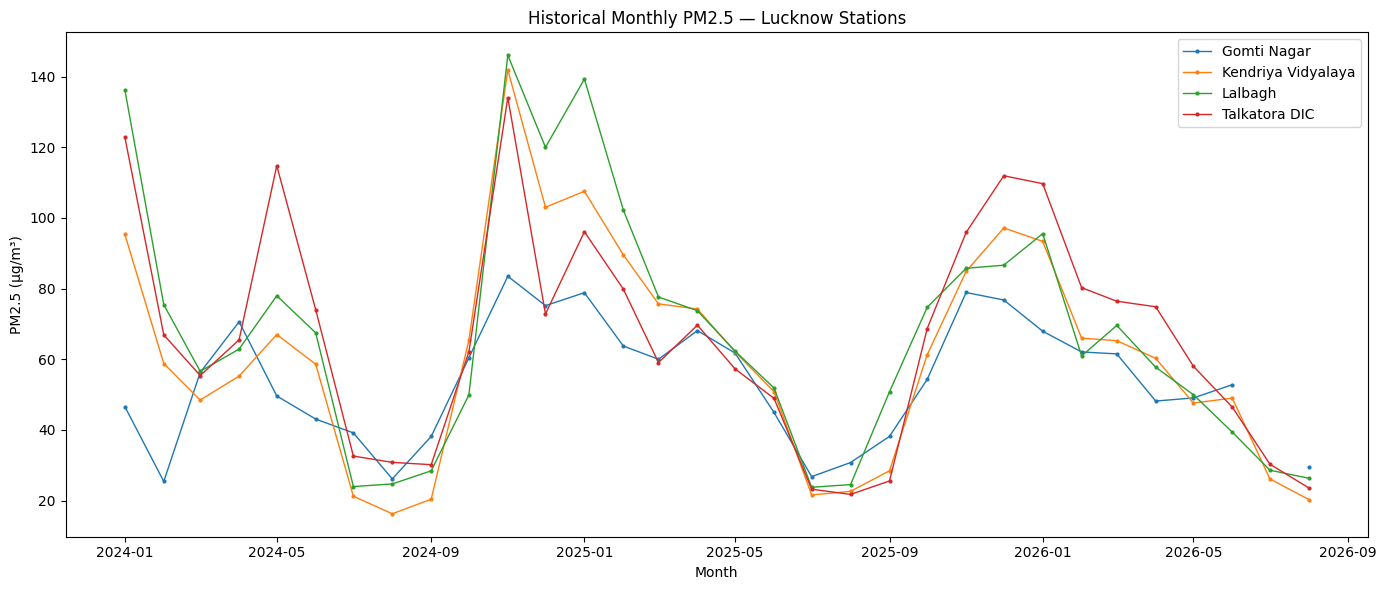

,count,mean,median,max
Station,,,,
Lalbagh,21643,68.11,56.88,897.80
Talkatora DIC,22564,66.21,56.64,975.77
Kendriya Vidyalaya,22648,61.15,51.76,886.80
Gomti Nagar,22064,53.99,47.75,827.00


In [40]:
# 31.2 Historical PM2.5 comparison across stations

plt.figure(figsize=(14, 6))

for station_name, g in multi_df.groupby("Station"):
    monthly = (
        g.set_index("Timestamp")[TARGET_DAY5]
        .resample("MS")
        .mean()
    )
    plt.plot(monthly.index, monthly.values, marker="o", markersize=2, linewidth=1, label=station_name)

plt.title("Historical Monthly PM2.5 — Lucknow Stations")
plt.xlabel("Month")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.tight_layout()
plt.show()

station_summary = (
    multi_df.groupby("Station")[TARGET_DAY5]
    .agg(["count", "mean", "median", "max"])
    .round(2)
    .sort_values("mean", ascending=False)
)

display(station_summary)


## 32. Station-Wise 24-Hour Forecasting

We now train a separate forecasting model for each station.

For every station:

**Past PM2.5 + time pattern → PM2.5 24 hours ahead**

Features use only information that would be available at prediction time:

- PM2.5 lags: 1, 3, 6, 12, 24, 48, 72, 168 hours
- rolling historical mean/std
- hour/day/month calendar features

The 2024–2025 period is used for training and 2026 is used as the chronological test period.

> This produces a **24-hour-ahead station forecast**, not a claim of certainty about tomorrow's pollution.


In [41]:
# 32.1 Feature engineering function

LAGS_DAY5 = [1, 3, 6, 12, 24, 48, 72, 168]
ROLLING_WINDOWS_DAY5 = [6, 12, 24, 72]

def build_station_features(station_frame):
    d = station_frame.sort_values("Timestamp").copy()

    # Calendar
    d["hour"] = d["Timestamp"].dt.hour
    d["day_of_week"] = d["Timestamp"].dt.dayofweek
    d["month"] = d["Timestamp"].dt.month
    d["day_of_year"] = d["Timestamp"].dt.dayofyear
    d["is_weekend"] = (d["day_of_week"] >= 5).astype(int)

    # Cyclic features
    d["hour_sin"] = np.sin(2 * np.pi * d["hour"] / 24)
    d["hour_cos"] = np.cos(2 * np.pi * d["hour"] / 24)
    d["month_sin"] = np.sin(2 * np.pi * d["month"] / 12)
    d["month_cos"] = np.cos(2 * np.pi * d["month"] / 12)

    # Historical PM2.5 lags
    for lag in LAGS_DAY5:
        d[f"pm25_lag_{lag}"] = d[TARGET_DAY5].shift(lag)

    # Rolling features based only on past observations
    for window in ROLLING_WINDOWS_DAY5:
        d[f"pm25_roll_mean_{window}"] = (
            d[TARGET_DAY5].shift(1).rolling(window).mean()
        )
        d[f"pm25_roll_std_{window}"] = (
            d[TARGET_DAY5].shift(1).rolling(window).std()
        )

    # Target: same station, 24 hours ahead
    d["target_pm25_24h"] = d[TARGET_DAY5].shift(-FORECAST_HORIZON_DAY5)

    feature_cols = [
        "hour", "day_of_week", "month", "day_of_year", "is_weekend",
        "hour_sin", "hour_cos", "month_sin", "month_cos"
    ]
    feature_cols += [f"pm25_lag_{lag}" for lag in LAGS_DAY5]
    feature_cols += [f"pm25_roll_mean_{w}" for w in ROLLING_WINDOWS_DAY5]
    feature_cols += [f"pm25_roll_std_{w}" for w in ROLLING_WINDOWS_DAY5]

    return d, feature_cols


In [42]:
# 32.2 Train and evaluate one model per station

station_models = {}
station_metrics = []
station_test_predictions = []

for station_name, station_frame in multi_df.groupby("Station"):
    station_data, features = build_station_features(station_frame)

    model_data_station = station_data.dropna(
        subset=features + ["target_pm25_24h"]
    ).copy()

    train_s = model_data_station[
        model_data_station["Timestamp"].dt.year < 2026
    ].copy()

    test_s = model_data_station[
        model_data_station["Timestamp"].dt.year == 2026
    ].copy()

    if len(train_s) < 500 or len(test_s) < 100:
        print(f"⚠️ Skipping {station_name}: insufficient usable train/test rows.")
        continue

    X_train_s = train_s[features]
    y_train_s = train_s["target_pm25_24h"]
    X_test_s = test_s[features]
    y_test_s = test_s["target_pm25_24h"]

    rf_s = RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=2,
        random_state=RANDOM_STATE_DAY5,
        n_jobs=-1
    )
    rf_s.fit(X_train_s, y_train_s)
    rf_pred_s = rf_s.predict(X_test_s)

    hgb_s = HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        random_state=RANDOM_STATE_DAY5
    )
    hgb_s.fit(X_train_s, y_train_s)
    hgb_pred_s = hgb_s.predict(X_test_s)

    rf_mae_s = mean_absolute_error(y_test_s, rf_pred_s)
    rf_rmse_s = np.sqrt(mean_squared_error(y_test_s, rf_pred_s))
    rf_r2_s = r2_score(y_test_s, rf_pred_s)

    hgb_mae_s = mean_absolute_error(y_test_s, hgb_pred_s)
    hgb_rmse_s = np.sqrt(mean_squared_error(y_test_s, hgb_pred_s))
    hgb_r2_s = r2_score(y_test_s, hgb_pred_s)

    if hgb_mae_s <= rf_mae_s:
        best_station_model = hgb_s
        best_station_pred = hgb_pred_s
        best_station_name = "HistGradientBoosting"
        best_station_mae = hgb_mae_s
        best_station_rmse = hgb_rmse_s
        best_station_r2 = hgb_r2_s
    else:
        best_station_model = rf_s
        best_station_pred = rf_pred_s
        best_station_name = "Random Forest"
        best_station_mae = rf_mae_s
        best_station_rmse = rf_rmse_s
        best_station_r2 = rf_r2_s

    station_models[station_name] = {
        "model": best_station_model,
        "features": features,
        "model_name": best_station_name,
        "train_start": str(train_s["Timestamp"].min()),
        "train_end": str(train_s["Timestamp"].max()),
        "test_start": str(test_s["Timestamp"].min()),
        "test_end": str(test_s["Timestamp"].max())
    }

    station_metrics.append({
        "Station": station_name,
        "Model": best_station_name,
        "Train rows": len(train_s),
        "Test rows": len(test_s),
        "MAE": round(best_station_mae, 3),
        "RMSE": round(best_station_rmse, 3),
        "R2": round(best_station_r2, 3)
    })

    pred_frame = test_s[["Timestamp", TARGET_DAY5]].copy()
    pred_frame["Station"] = station_name
    pred_frame["Actual_PM2.5_24h"] = test_s["target_pm25_24h"].values
    pred_frame["Predicted_PM2.5_24h"] = best_station_pred
    station_test_predictions.append(pred_frame)

station_metrics_df = pd.DataFrame(station_metrics).sort_values("MAE").reset_index(drop=True)
station_test_predictions_df = pd.concat(station_test_predictions, ignore_index=True)

print("Station model results:")
display(station_metrics_df)


Station model results:


,Station,Model,Train rows,Test rows,MAE,RMSE,R2
0,Kendriya Vidyalaya,HistGradientBoosting,7046,2293,16.652,24.836,0.430
1,Talkatora DIC,Random Forest,8110,3026,19.278,27.090,0.504
2,Gomti Nagar,Random Forest,11106,3871,20.982,32.617,0.011
3,Lalbagh,Random Forest,5085,789,22.994,29.737,-0.199


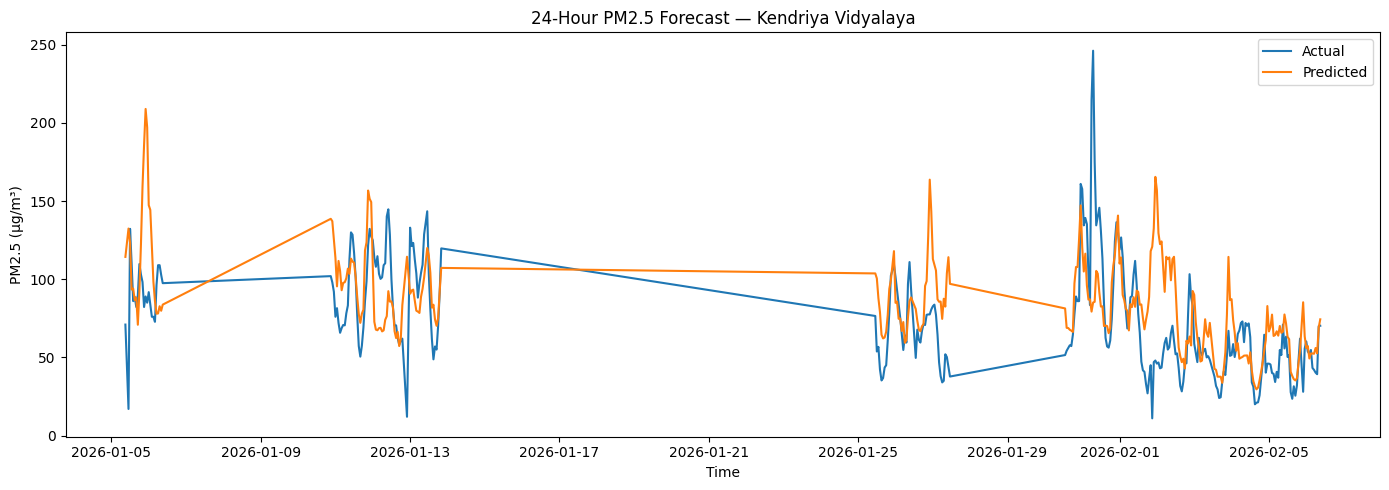

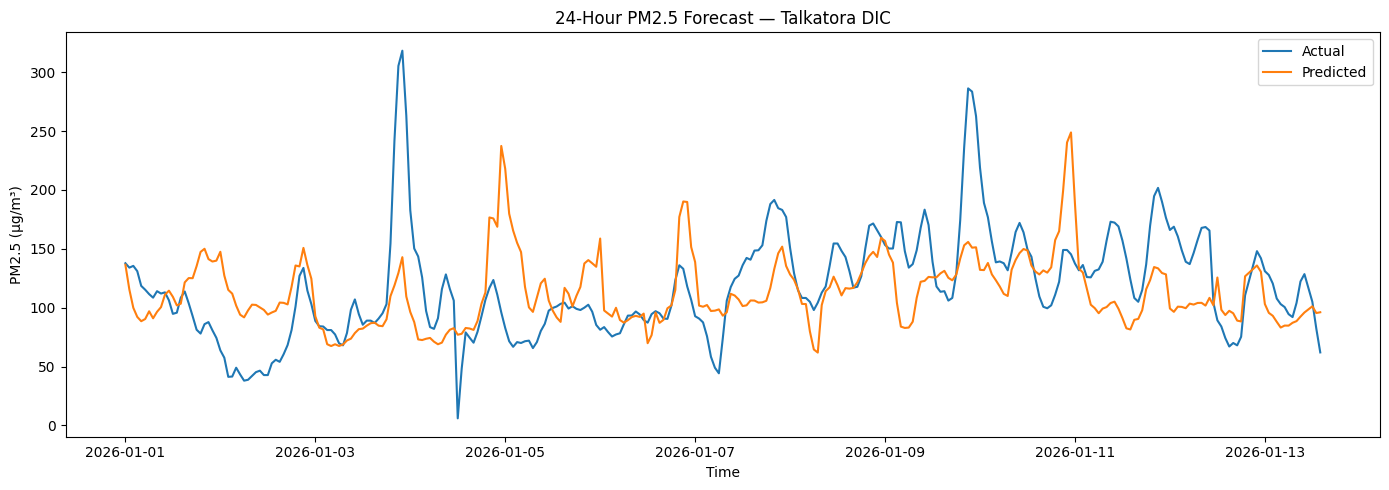

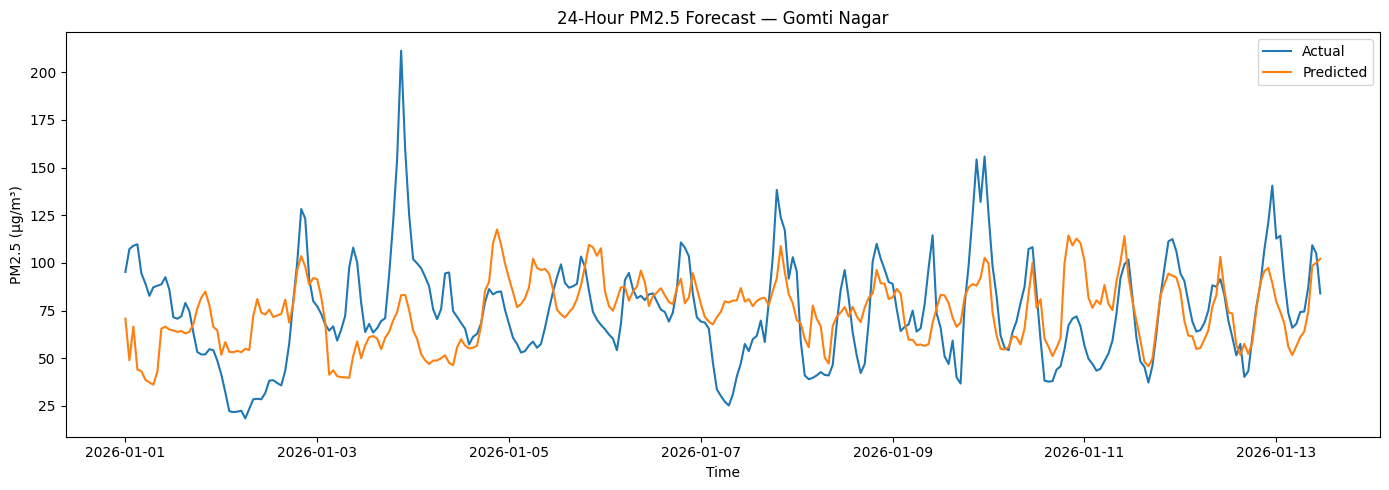

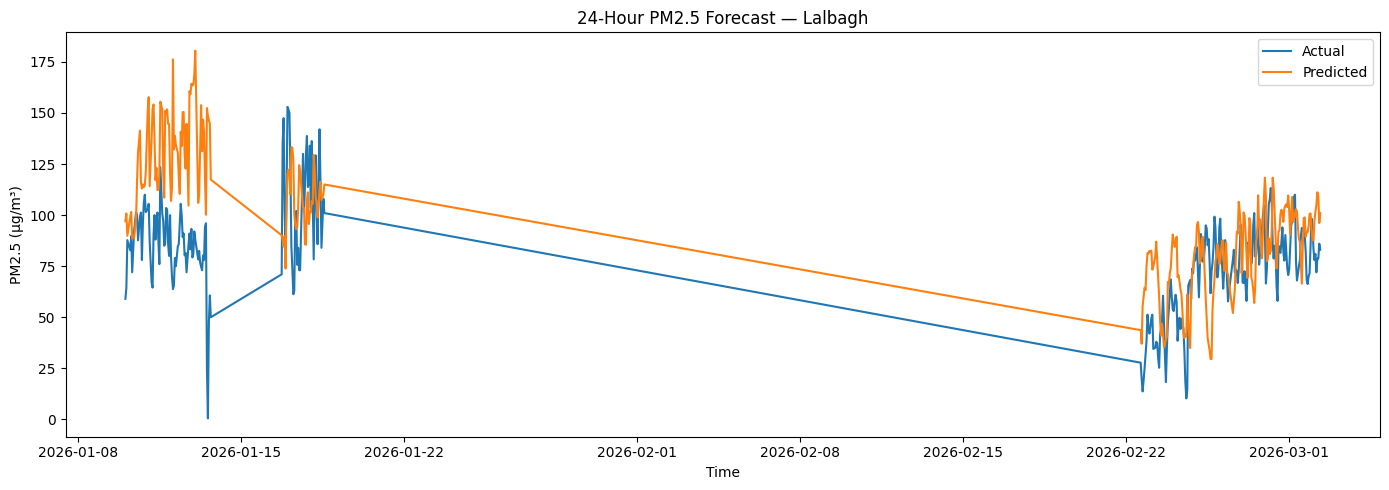

In [43]:
# 32.3 Visualize station-wise forecast performance

for station_name in station_metrics_df["Station"]:
    p = station_test_predictions_df[
        station_test_predictions_df["Station"] == station_name
    ].sort_values("Timestamp")

    n = min(300, len(p))

    plt.figure(figsize=(14, 5))
    plt.plot(
        p["Timestamp"].iloc[:n],
        p["Actual_PM2.5_24h"].iloc[:n],
        label="Actual"
    )
    plt.plot(
        p["Timestamp"].iloc[:n],
        p["Predicted_PM2.5_24h"].iloc[:n],
        label="Predicted"
    )
    plt.title(f"24-Hour PM2.5 Forecast — {station_name}")
    plt.xlabel("Time")
    plt.ylabel("PM2.5 (µg/m³)")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 33. Station-Wise Anomaly Detection

Each station gets its own Isolation Forest.

An anomaly means:

> The observation looks unusual compared with that station's historical environmental pattern.

It is a **screening signal**, not proof of a regulatory violation.


In [44]:
# 33.1 Train station-specific anomaly detectors

station_anomaly_models = {}
station_anomaly_results = []

ANOMALY_CONTEXT_COLS = [
    TARGET_DAY5,
    "PM10 (µg/m³)",
    "NO2 (µg/m³)",
    "SO2 (µg/m³)",
    "CO (mg/m³)",
    "Ozone (µg/m³)",
    "AT (°C)",
    "RH (%)",
    "WS (m/s)"
]

for station_name, station_frame in multi_df.groupby("Station"):
    a = station_frame[["Timestamp"] + [
        c for c in ANOMALY_CONTEXT_COLS if c in station_frame.columns
    ]].copy()

    a["hour"] = a["Timestamp"].dt.hour
    a["day_of_week"] = a["Timestamp"].dt.dayofweek

    anomaly_features = [
        c for c in a.columns
        if c != "Timestamp"
    ]

    X_a = a[anomaly_features].copy()
    X_a = X_a.replace([np.inf, -np.inf], np.nan)
    X_a = X_a.fillna(X_a.median(numeric_only=True))
    X_a = X_a.fillna(0)

    iso_s = IsolationForest(
        n_estimators=200,
        contamination=0.03,
        random_state=RANDOM_STATE_DAY5
    )
    iso_s.fit(X_a)

    a["anomaly_label"] = iso_s.predict(X_a)
    a["anomaly_score"] = -iso_s.score_samples(X_a)
    a["is_anomaly"] = (a["anomaly_label"] == -1).astype(int)
    a["Station"] = station_name

    station_anomaly_models[station_name] = {
        "model": iso_s,
        "features": anomaly_features
    }

    station_anomaly_results.append(
        a[["Timestamp", "Station", TARGET_DAY5, "anomaly_score", "is_anomaly"]]
    )

anomaly_results_day5 = pd.concat(
    station_anomaly_results,
    ignore_index=True
)

anomaly_summary = (
    anomaly_results_day5.groupby("Station")["is_anomaly"]
    .agg(["sum", "mean"])
    .rename(columns={"sum": "Anomalies", "mean": "Anomaly Rate"})
)

anomaly_summary["Anomaly Rate"] = (
    anomaly_summary["Anomaly Rate"] * 100
).round(2)

display(anomaly_summary)


,Anomalies,Anomaly Rate
Station,,
Gomti Nagar,679,3.0
Kendriya Vidyalaya,702,3.0
Lalbagh,702,3.0
Talkatora DIC,702,3.0


## 34. Tomorrow's Station Risk

The risk score combines:

1. Current PM2.5
2. 24-hour-ahead predicted PM2.5
3. Recent PM2.5 behaviour
4. Current anomaly signal

The score is a **prototype prioritization indicator**.

It is not an official CPCB AQI category and it is not an enforcement decision.


In [45]:
# 34.1 Calculate latest 24-hour-ahead forecast and risk for every station

def risk_category_day5(score):
    if score < 25:
        return "Low"
    elif score < 50:
        return "Moderate"
    elif score < 75:
        return "High"
    return "Critical"

latest_station_rows = []

for station_name, station_frame in multi_df.groupby("Station"):
    if station_name not in station_models:
        continue

    g = station_frame.sort_values("Timestamp").copy()

    # Last valid/current PM2.5 observation
    valid_pm = g.dropna(subset=[TARGET_DAY5])
    if valid_pm.empty:
        continue

    latest_valid = valid_pm.iloc[-1]
    current_pm25 = float(latest_valid[TARGET_DAY5])
    latest_timestamp = latest_valid["Timestamp"]

    # Build features using the latest available history
    feature_frame, features = build_station_features(g)

    usable_features = feature_frame.dropna(subset=features)
    if usable_features.empty:
        continue

    latest_features = usable_features.iloc[[-1]]
    model_package = station_models[station_name]
    predicted_pm25 = float(
        model_package["model"].predict(latest_features[features])[0]
    )

    # Recent mean
    recent = valid_pm.tail(24)
    recent_mean = float(recent[TARGET_DAY5].mean())

    # Latest anomaly
    a = anomaly_results_day5[
        (anomaly_results_day5["Station"] == station_name) &
        (anomaly_results_day5["Timestamp"] == latest_timestamp)
    ]

    if len(a):
        is_anomaly = int(a["is_anomaly"].iloc[-1])
    else:
        # If exact timestamp is not in anomaly table, use latest station record
        a2 = anomaly_results_day5[
            anomaly_results_day5["Station"] == station_name
        ].sort_values("Timestamp")
        is_anomaly = int(a2["is_anomaly"].iloc[-1]) if len(a2) else 0

    # Transparent 0–100 prototype score.
    current_component = np.clip(current_pm25 / 200 * 30, 0, 30)
    forecast_component = np.clip(predicted_pm25 / 200 * 45, 0, 45)
    recent_component = np.clip(recent_mean / 200 * 15, 0, 15)
    anomaly_component = is_anomaly * 10

    risk_score = float(np.clip(
        current_component +
        forecast_component +
        recent_component +
        anomaly_component,
        0,
        100
    ))

    latest_station_rows.append({
        "Station": station_name,
        "Latest timestamp": latest_timestamp,
        "Current PM2.5": round(current_pm25, 2),
        "24h Forecast PM2.5": round(predicted_pm25, 2),
        "Recent 24h Mean PM2.5": round(recent_mean, 2),
        "Anomaly": is_anomaly,
        "Risk Score": round(risk_score, 2),
        "Tomorrow Risk": risk_category_day5(risk_score),
        "Forecast Model": model_package["model_name"]
    })

tomorrow_risk = pd.DataFrame(latest_station_rows)

if tomorrow_risk.empty:
    raise RuntimeError("No station-level forecasts were produced.")

tomorrow_risk = tomorrow_risk.sort_values(
    "Risk Score",
    ascending=False
).reset_index(drop=True)

tomorrow_risk["Tomorrow Priority Rank"] = np.arange(
    1, len(tomorrow_risk) + 1
)

display(
    tomorrow_risk[
        [
            "Tomorrow Priority Rank",
            "Station",
            "Current PM2.5",
            "24h Forecast PM2.5",
            "Recent 24h Mean PM2.5",
            "Anomaly",
            "Risk Score",
            "Tomorrow Risk",
            "Forecast Model"
        ]
    ]
)


,Tomorrow Priority Rank,Station,Current PM2.5,24h Forecast PM2.5,Recent 24h Mean PM2.5,Anomaly,Risk Score,Tomorrow Risk,Forecast Model
0,1,Lalbagh,30.87,41.86,24.70,0,15.90,Low,Random Forest
1,2,Gomti Nagar,11.33,29.11,28.57,0,10.39,Low,Random Forest
2,3,Talkatora DIC,24.41,21.78,18.64,0,9.96,Low,Random Forest
3,4,Kendriya Vidyalaya,11.98,20.72,19.77,0,7.94,Low,HistGradientBoosting


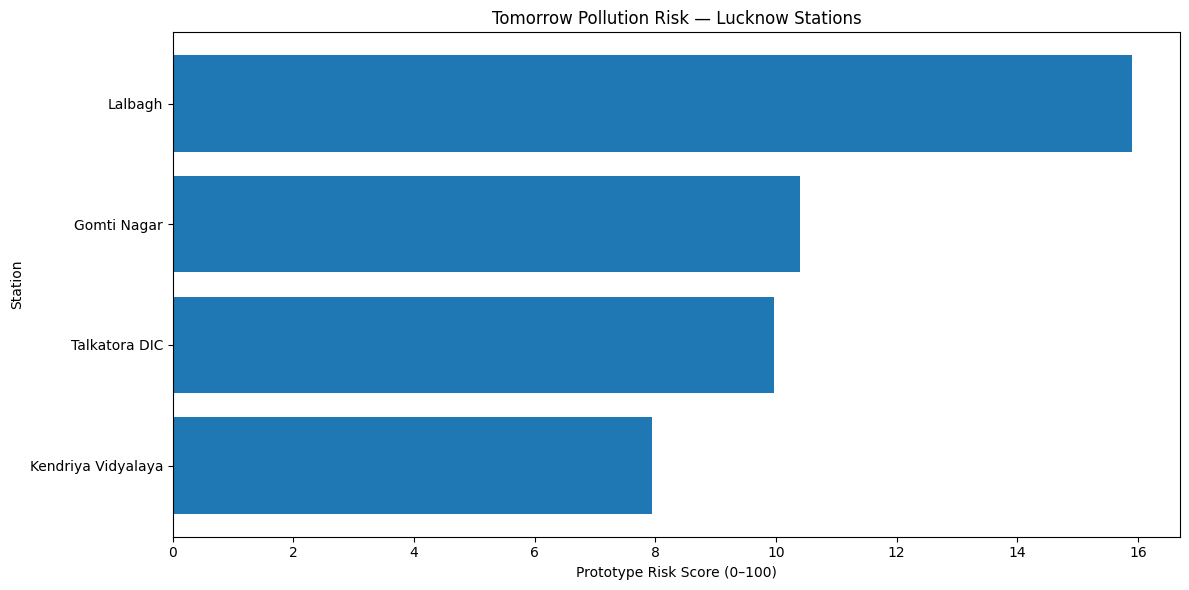

In [46]:
# 34.2 Visualize tomorrow's station forecast/risk comparison

plt.figure(figsize=(12, 6))

plot_df = tomorrow_risk.sort_values("Risk Score", ascending=True)

plt.barh(
    plot_df["Station"],
    plot_df["Risk Score"]
)

plt.xlabel("Prototype Risk Score (0–100)")
plt.ylabel("Station")
plt.title("Tomorrow Pollution Risk — Lucknow Stations")
plt.tight_layout()
plt.show()


## 35. Inspection Priority

Now the earlier single-station limitation is removed.

Instead of ranking individual timestamps from one station, Eco Predict ranks **monitoring stations against each other**.

The interpretation is:

> **Which station deserves attention first based on current conditions, tomorrow's forecast, recent behaviour and anomaly signals?**

This remains a decision-support ranking, not an automatic enforcement action.


In [47]:
# 35.1 Create the station inspection priority table

priority = tomorrow_risk.copy()

priority["Inspection Priority Score"] = (
    priority["Risk Score"] +
    priority["Anomaly"] * 5
).clip(upper=100)

priority = priority.sort_values(
    ["Inspection Priority Score", "24h Forecast PM2.5"],
    ascending=[False, False]
).reset_index(drop=True)

priority["Inspection Rank"] = np.arange(1, len(priority) + 1)

def priority_level_day5(score):
    if score < 30:
        return "Monitor"
    elif score < 55:
        return "Review"
    elif score < 75:
        return "High Priority"
    return "Urgent Review"

priority["Inspection Level"] = priority[
    "Inspection Priority Score"
].apply(priority_level_day5)

priority_output = priority[
    [
        "Inspection Rank",
        "Station",
        "Current PM2.5",
        "24h Forecast PM2.5",
        "Anomaly",
        "Risk Score",
        "Tomorrow Risk",
        "Inspection Priority Score",
        "Inspection Level"
    ]
]

display(priority_output)


,Inspection Rank,Station,Current PM2.5,24h Forecast PM2.5,Anomaly,Risk Score,Tomorrow Risk,Inspection Priority Score,Inspection Level
0,1,Lalbagh,30.87,41.86,0,15.90,Low,15.90,Monitor
1,2,Gomti Nagar,11.33,29.11,0,10.39,Low,10.39,Monitor
2,3,Talkatora DIC,24.41,21.78,0,9.96,Low,9.96,Monitor
3,4,Kendriya Vidyalaya,11.98,20.72,0,7.94,Low,7.94,Monitor


## 36. Save Day 5 Artifacts

The outputs created here will later be consumed by the FastAPI backend and React frontend.

Saved artifacts include:

- combined multi-station dataset
- station quality report
- station forecasting metrics
- station forecasts
- tomorrow risk ranking
- inspection priority
- station forecasting models
- station anomaly models


In [48]:
# 36.1 Save processed data, metrics, rankings and models

multi_station_path = os.path.join(
    PROCESSED_DIR_DAY5,
    "lucknow_multi_station.csv"
)

quality_path = os.path.join(
    PROCESSED_DIR_DAY5,
    "station_quality_report.csv"
)

metrics_path = os.path.join(
    MODEL_DIR_DAY5,
    "station_forecast_metrics.csv"
)

forecast_path = os.path.join(
    OUTPUT_DIR_DAY5,
    "station_forecast_results.csv"
)

risk_path = os.path.join(
    OUTPUT_DIR_DAY5,
    "tomorrow_station_risk.csv"
)

priority_path = os.path.join(
    OUTPUT_DIR_DAY5,
    "station_inspection_priority.csv"
)

multi_df.to_csv(multi_station_path, index=False)
station_quality.to_csv(quality_path, index=False)
station_metrics_df.to_csv(metrics_path, index=False)
station_test_predictions_df.to_csv(forecast_path, index=False)
tomorrow_risk.to_csv(risk_path, index=False)
priority_output.to_csv(priority_path, index=False)

# Save each station forecasting model
for station_name, package in station_models.items():
    safe_name = (
        station_name.lower()
        .replace(" ", "_")
        .replace("-", "_")
    )
    model_path = os.path.join(
        MODEL_DIR_DAY5,
        f"pm25_forecaster_24h_{safe_name}.joblib"
    )
    joblib.dump(package, model_path)

# Save each station anomaly model
for station_name, package in station_anomaly_models.items():
    safe_name = (
        station_name.lower()
        .replace(" ", "_")
        .replace("-", "_")
    )
    model_path = os.path.join(
        MODEL_DIR_DAY5,
        f"pm25_anomaly_detector_{safe_name}.joblib"
    )
    joblib.dump(package, model_path)

# Backend-friendly latest intelligence JSON
latest_intelligence_day5 = {
    "city": "Lucknow",
    "forecast_horizon_hours": 24,
    "stations": tomorrow_risk.to_dict(orient="records"),
    "inspection_priority": priority_output.to_dict(orient="records"),
    "note": (
        "Risk and priority values are prototype decision-support indicators. "
        "They are not official regulatory classifications."
    )
}

latest_json_path = os.path.join(
    OUTPUT_DIR_DAY5,
    "latest_lucknow_intelligence.json"
)

with open(latest_json_path, "w", encoding="utf-8") as f:
    json.dump(latest_intelligence_day5, f, indent=4, default=str)

print("✅ Day 5 artifacts saved:")
for p in [
    multi_station_path,
    quality_path,
    metrics_path,
    forecast_path,
    risk_path,
    priority_path,
    latest_json_path
]:
    print(" -", p)


✅ Day 5 artifacts saved:
 - C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\data\processed\lucknow_multi_station.csv
 - C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\data\processed\station_quality_report.csv
 - C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\models\multi_station\station_forecast_metrics.csv
 - C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\outputs\multi_station\station_forecast_results.csv
 - C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\outputs\multi_station\tomorrow_station_risk.csv
 - C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\outputs\multi_station\station_inspection_priority.csv
 - C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\outputs\multi_station\latest_lucknow_intelligence.json


# ✅ DAY 5 COMPLETE

Eco Predict has now moved from a single monitoring station to a **multi-station Lucknow intelligence layer**.

### Completed

- ✅ Four-station historical data ingestion
- ✅ Automatic station identification from folders
- ✅ Data quality and coverage analysis
- ✅ Station comparison
- ✅ Separate 24-hour PM2.5 forecasting model per station
- ✅ Station-specific anomaly detection
- ✅ Tomorrow pollution-risk scoring
- ✅ Cross-station inspection priority ranking
- ✅ Backend-ready CSV/JSON outputs
- ✅ Station-specific `.joblib` model artifacts

### The new intelligence question

Eco Predict can now work toward answering:

> **“Which Lucknow monitoring station has the highest predicted pollution risk over the next 24 hours?”**

### Next

**Day 6 → FastAPI backend**

```text
React Frontend
      ↕
   FastAPI
      ↕
Day 5 ML + Data
```
